# Postprocessing

Makes control plots and templates.

Authors: Raghav Kansal, Cristina Suarez

In [1]:
from __future__ import annotations

import os
from copy import deepcopy

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mplhep as hep
import numpy as np
import pandas as pd

from HH4b import plotting, postprocessing, utils
from HH4b.hh_vars import LUMI, bg_keys, data_key, sig_keys
from HH4b.postprocessing import Region
from HH4b.utils import CUT_MAX_VAL, ShapeVar

plt.style.use(hep.style.CMS)
hep.style.use("CMS")
formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
plt.rcParams.update({"font.size": 16})

In [2]:
# automatically reloads imported files on edits
%load_ext autoreload
%autoreload 2

In [12]:
MAIN_DIR = "../../../"
path_to_dir = f"{MAIN_DIR}/../data/skimmer/23Nov16_v9_privatepfnano/"
# path_to_dir = f"{MAIN_DIR}/../data/skimmer/23Nov13_v9_private/"

year = "2018"

# make plot and template directory
# date = "23Nov16_2018"
# date = "23Nov13_2018"
date = "24Feb1_2018"

plot_dir = f"{MAIN_DIR}/plots/PostProcessing/{date}/{year}"
template_dir = f"templates/{date}/"
_ = os.system(f"mkdir -p {plot_dir}")
_ = os.system(f"mkdir -p {template_dir}/cutflows/{year}")

from HH4b.hh_vars import samples

samples = deepcopy(samples[year])
sig_keys = ["hh4b"]
for key in list(samples.keys()):
    if key not in bg_keys + sig_keys + [data_key]:
        del samples[key]

sample_dirs = {path_to_dir: samples}

In [13]:
sample_dirs

{'../../..//../data/skimmer/23Nov16_v9_privatepfnano/': {'hh4b': ['GluGlutoHHto4B_cHHH1_TuneCP5_PSWeights_13TeV-powheg-pythia8'],
  'qcd': ['QCD_HT-1000to1500-13TeV',
   'QCD_HT-1500to2000-13TeV',
   'QCD_HT-2000toInf-13TeV',
   'QCD_HT-200to300-13TeV',
   'QCD_HT-300to500-13TeV',
   'QCD_HT-500to700-13TeV',
   'QCD_HT-700to1000-13TeV'],
  'data': ['Run2018A', 'Run2018B', 'Run2018C', 'Run2018D'],
  'ttbar': ['TTTo2L2Nu_13TeV', 'TTToHadronic_13TeV', 'TTToSemiLeptonic_13TeV'],
  'vjets': ['WJetsToQQ_HT-200to400_13TeV',
   'WJetsToQQ_HT-400to600_13TeV',
   'WJetsToQQ_HT-600to800_13TeV',
   'WJetsToQQ_HT-800toInf_13TeV',
   'ZJetsToQQ_HT-200to400_13TeV',
   'ZJetsToQQ_HT-400to600_13TeV',
   'ZJetsToQQ_HT-600to800_13TeV',
   'ZJetsToQQ_HT-800toInf_13TeV'],
  'diboson': ['ZZ_TuneCP5_13TeV-pythia8'],
  'gghtobb': ['GluGluHToBB_Pt-200ToInf_M-125_TuneCP5_MINLO_13TeV-powheg-pythia8'],
  'vbfhtobb': ['VBFHToBB_M-125_dipoleRecoilOn_TuneCP5_13TeV-powheg-pythia8'],
  'vhtobb': ['WminusH_HToBB_WToQQ_

In [14]:
filters = [
    [
        ("('ak8FatJetPt', '0')", ">=", 300),
        ("('ak8FatJetPt', '1')", ">=", 300),
        ("('ak8FatJetMsd', '0')", ">=", 50),
        ("('ak8FatJetMsd', '1')", ">=", 50),
        ("('ak8FatJetPNetXbb', '0')", ">=", 0.8),
    ],
    [
        ("('ak8FatJetPt', '0')", ">=", 300),
        ("('ak8FatJetPt', '1')", ">=", 300),
        ("('ak8FatJetMsd', '0')", ">=", 50),
        ("('ak8FatJetMsd', '1')", ">=", 50),
        ("('ak8FatJetPNetXbb', '1')", ">=", 0.8),
    ],
    [
        ("('ak8FatJetPt', '0')", ">=", 300),
        ("('ak8FatJetPt', '1')", ">=", 300),
        ("('ak8FatJetPNetMass', '0')", ">=", 50),
        ("('ak8FatJetPNetMass', '1')", ">=", 50),
        ("('ak8FatJetPNetXbb', '0')", ">=", 0.8),
    ],
    [
        ("('ak8FatJetPt', '0')", ">=", 300),
        ("('ak8FatJetPt', '1')", ">=", 300),
        ("('ak8FatJetPNetMass', '0')", ">=", 50),
        ("('ak8FatJetPNetMass', '1')", ">=", 50),
        ("('ak8FatJetPNetXbb', '1')", ">=", 0.8),
    ],
]

# save cutflow as pandas table
cutflow = pd.DataFrame(index=list(samples.keys()))

# dictionary that will contain all information (from all samples)
events_dict = {}
for input_dir, samples in sample_dirs.items():
    events_dict = {
        **events_dict,
        # this function will load files (only the columns selected), apply filters and compute a weight per event
        **utils.load_samples(
            input_dir,
            samples,
            year,
            filters=filters,
        ),
    }

utils.add_to_cutflow(events_dict, "Preselection", "weight", cutflow)
print("\n", cutflow)

Loading GluGlutoHHto4B_cHHH1_TuneCP5_PSWeights_13TeV-powheg-pythia8
Loading QCD_HT-200to300-13TeV
Loading QCD_HT-1000to1500-13TeV
Loading QCD_HT-500to700-13TeV
Loading QCD_HT-700to1000-13TeV
Loading QCD_HT-300to500-13TeV
Loading QCD_HT-1500to2000-13TeV
Loading QCD_HT-2000toInf-13TeV
Loading Run2018A
Loading Run2018C
Loading Run2018D
Loading Run2018B
Loading TTToHadronic_13TeV
Loading TTToSemiLeptonic_13TeV
Loading TTTo2L2Nu_13TeV
Loading ZJetsToQQ_HT-400to600_13TeV
Loading WJetsToQQ_HT-600to800_13TeV
Loading WJetsToQQ_HT-800toInf_13TeV
Loading WJetsToQQ_HT-200to400_13TeV
Loading ZJetsToQQ_HT-200to400_13TeV
Loading ZJetsToQQ_HT-800toInf_13TeV
Loading ZJetsToQQ_HT-600to800_13TeV


Loading WJetsToQQ_HT-400to600_13TeV
Loading ZZ_TuneCP5_13TeV-pythia8
Loading GluGluHToBB_Pt-200ToInf_M-125_TuneCP5_MINLO_13TeV-powheg-pythia8
Loading VBFHToBB_M-125_dipoleRecoilOn_TuneCP5_13TeV-powheg-pythia8
Loading ZH_HToBB_ZToQQ_M-125_TuneCP5_13TeV-powheg-pythia8
Loading ttHTobb_M125_TuneCP5_13TeV-powheg-pythia8

            Preselection
hh4b           3.539087
qcd       893917.933282
data      674263.000000
ttbar     107194.904848
vjets      23115.885774
diboson      160.799180
gghtobb      200.690308
vbfhtobb      46.251761
vhtobb        58.708373
tthtobb      295.081445


In [15]:
events_dict["qcd"] = events_dict["qcd"][(events_dict["qcd"]["weight"] < 8e2).values]

In [16]:
bb_masks = postprocessing.bb_assignment(events_dict)
bb_masks

{'hh4b':            0      1
 0       True  False
 1       True  False
 2       True  False
 3       True  False
 4      False   True
 ...      ...    ...
 12300  False   True
 12301   True  False
 12302  False   True
 12303  False   True
 12304  False   True
 
 [12305 rows x 2 columns],
 'qcd':            0      1
 0       True  False
 1       True  False
 2      False   True
 3      False   True
 4       True  False
 ...      ...    ...
 46073  False   True
 46074   True  False
 46075  False   True
 46076  False   True
 46077   True  False
 
 [200547 rows x 2 columns],
 'data':            0      1
 0       True  False
 1      False   True
 2      False   True
 3       True  False
 4      False   True
 ...      ...    ...
 75944   True  False
 75945  False   True
 75946   True  False
 75947   True  False
 75948   True  False
 
 [674263 rows x 2 columns],
 'ttbar':            0      1
 0      False   True
 1       True  False
 2       True  False
 3       True  False
 4      False   Tr

### Control Plots

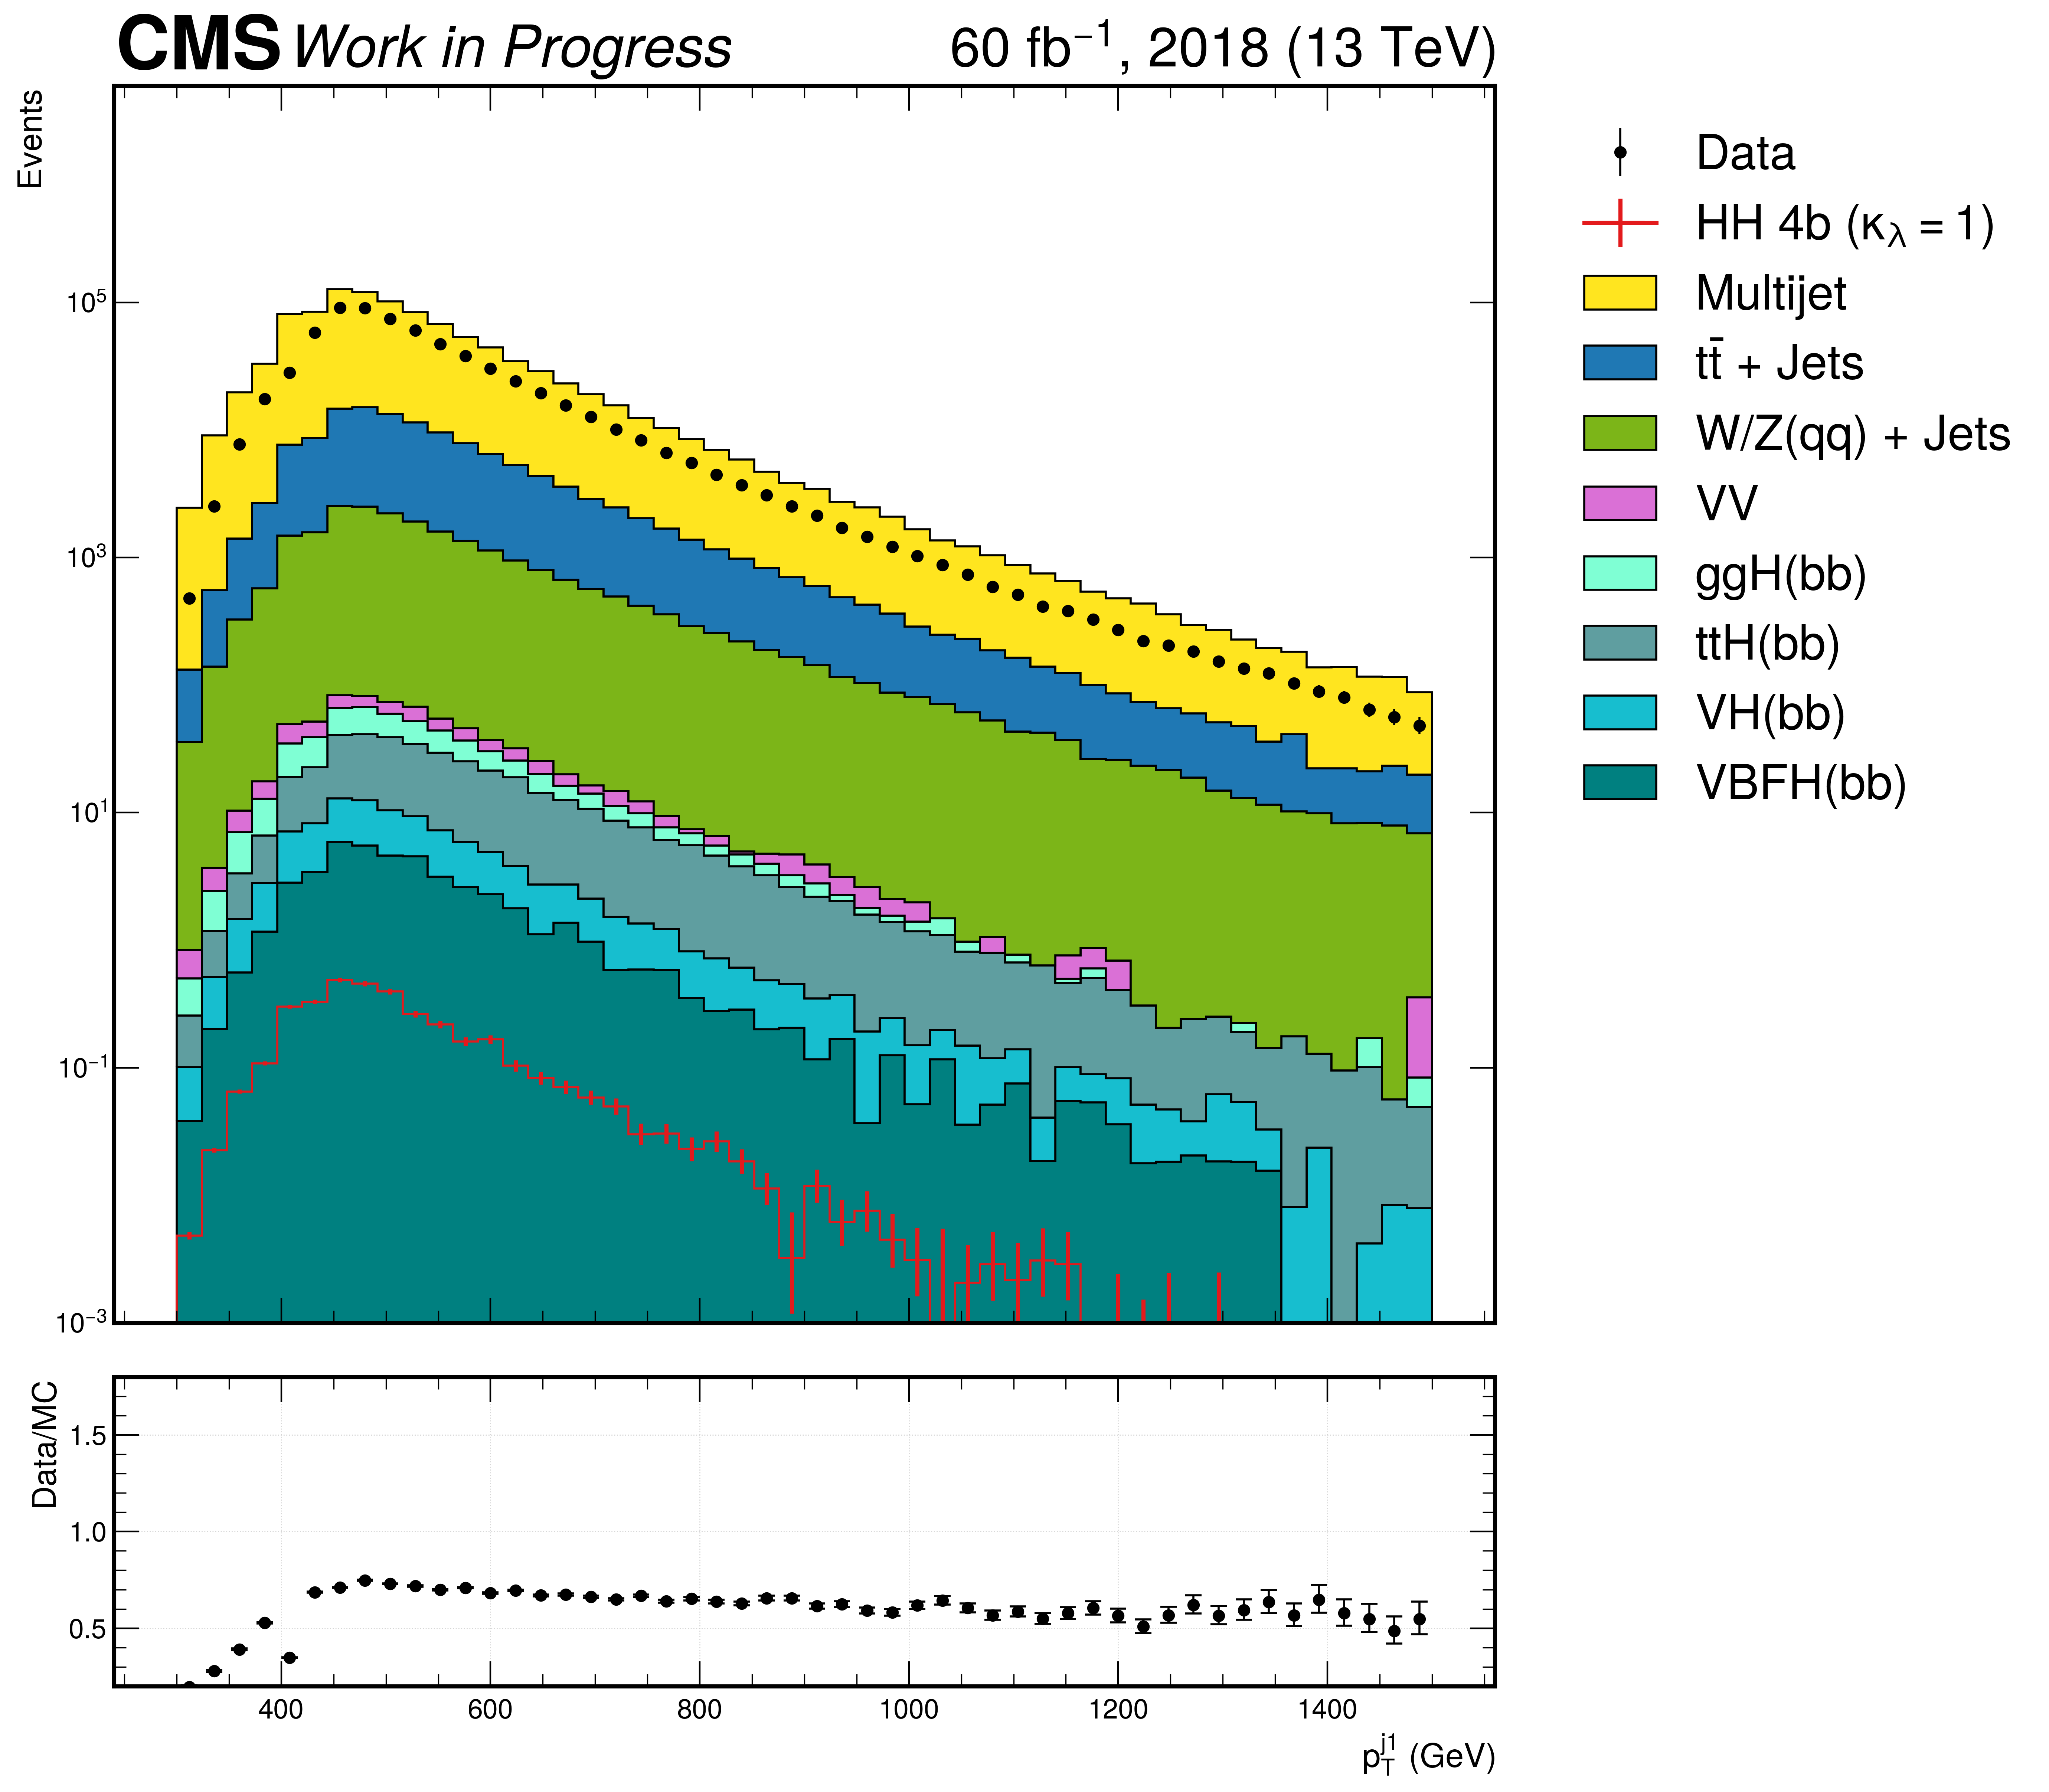

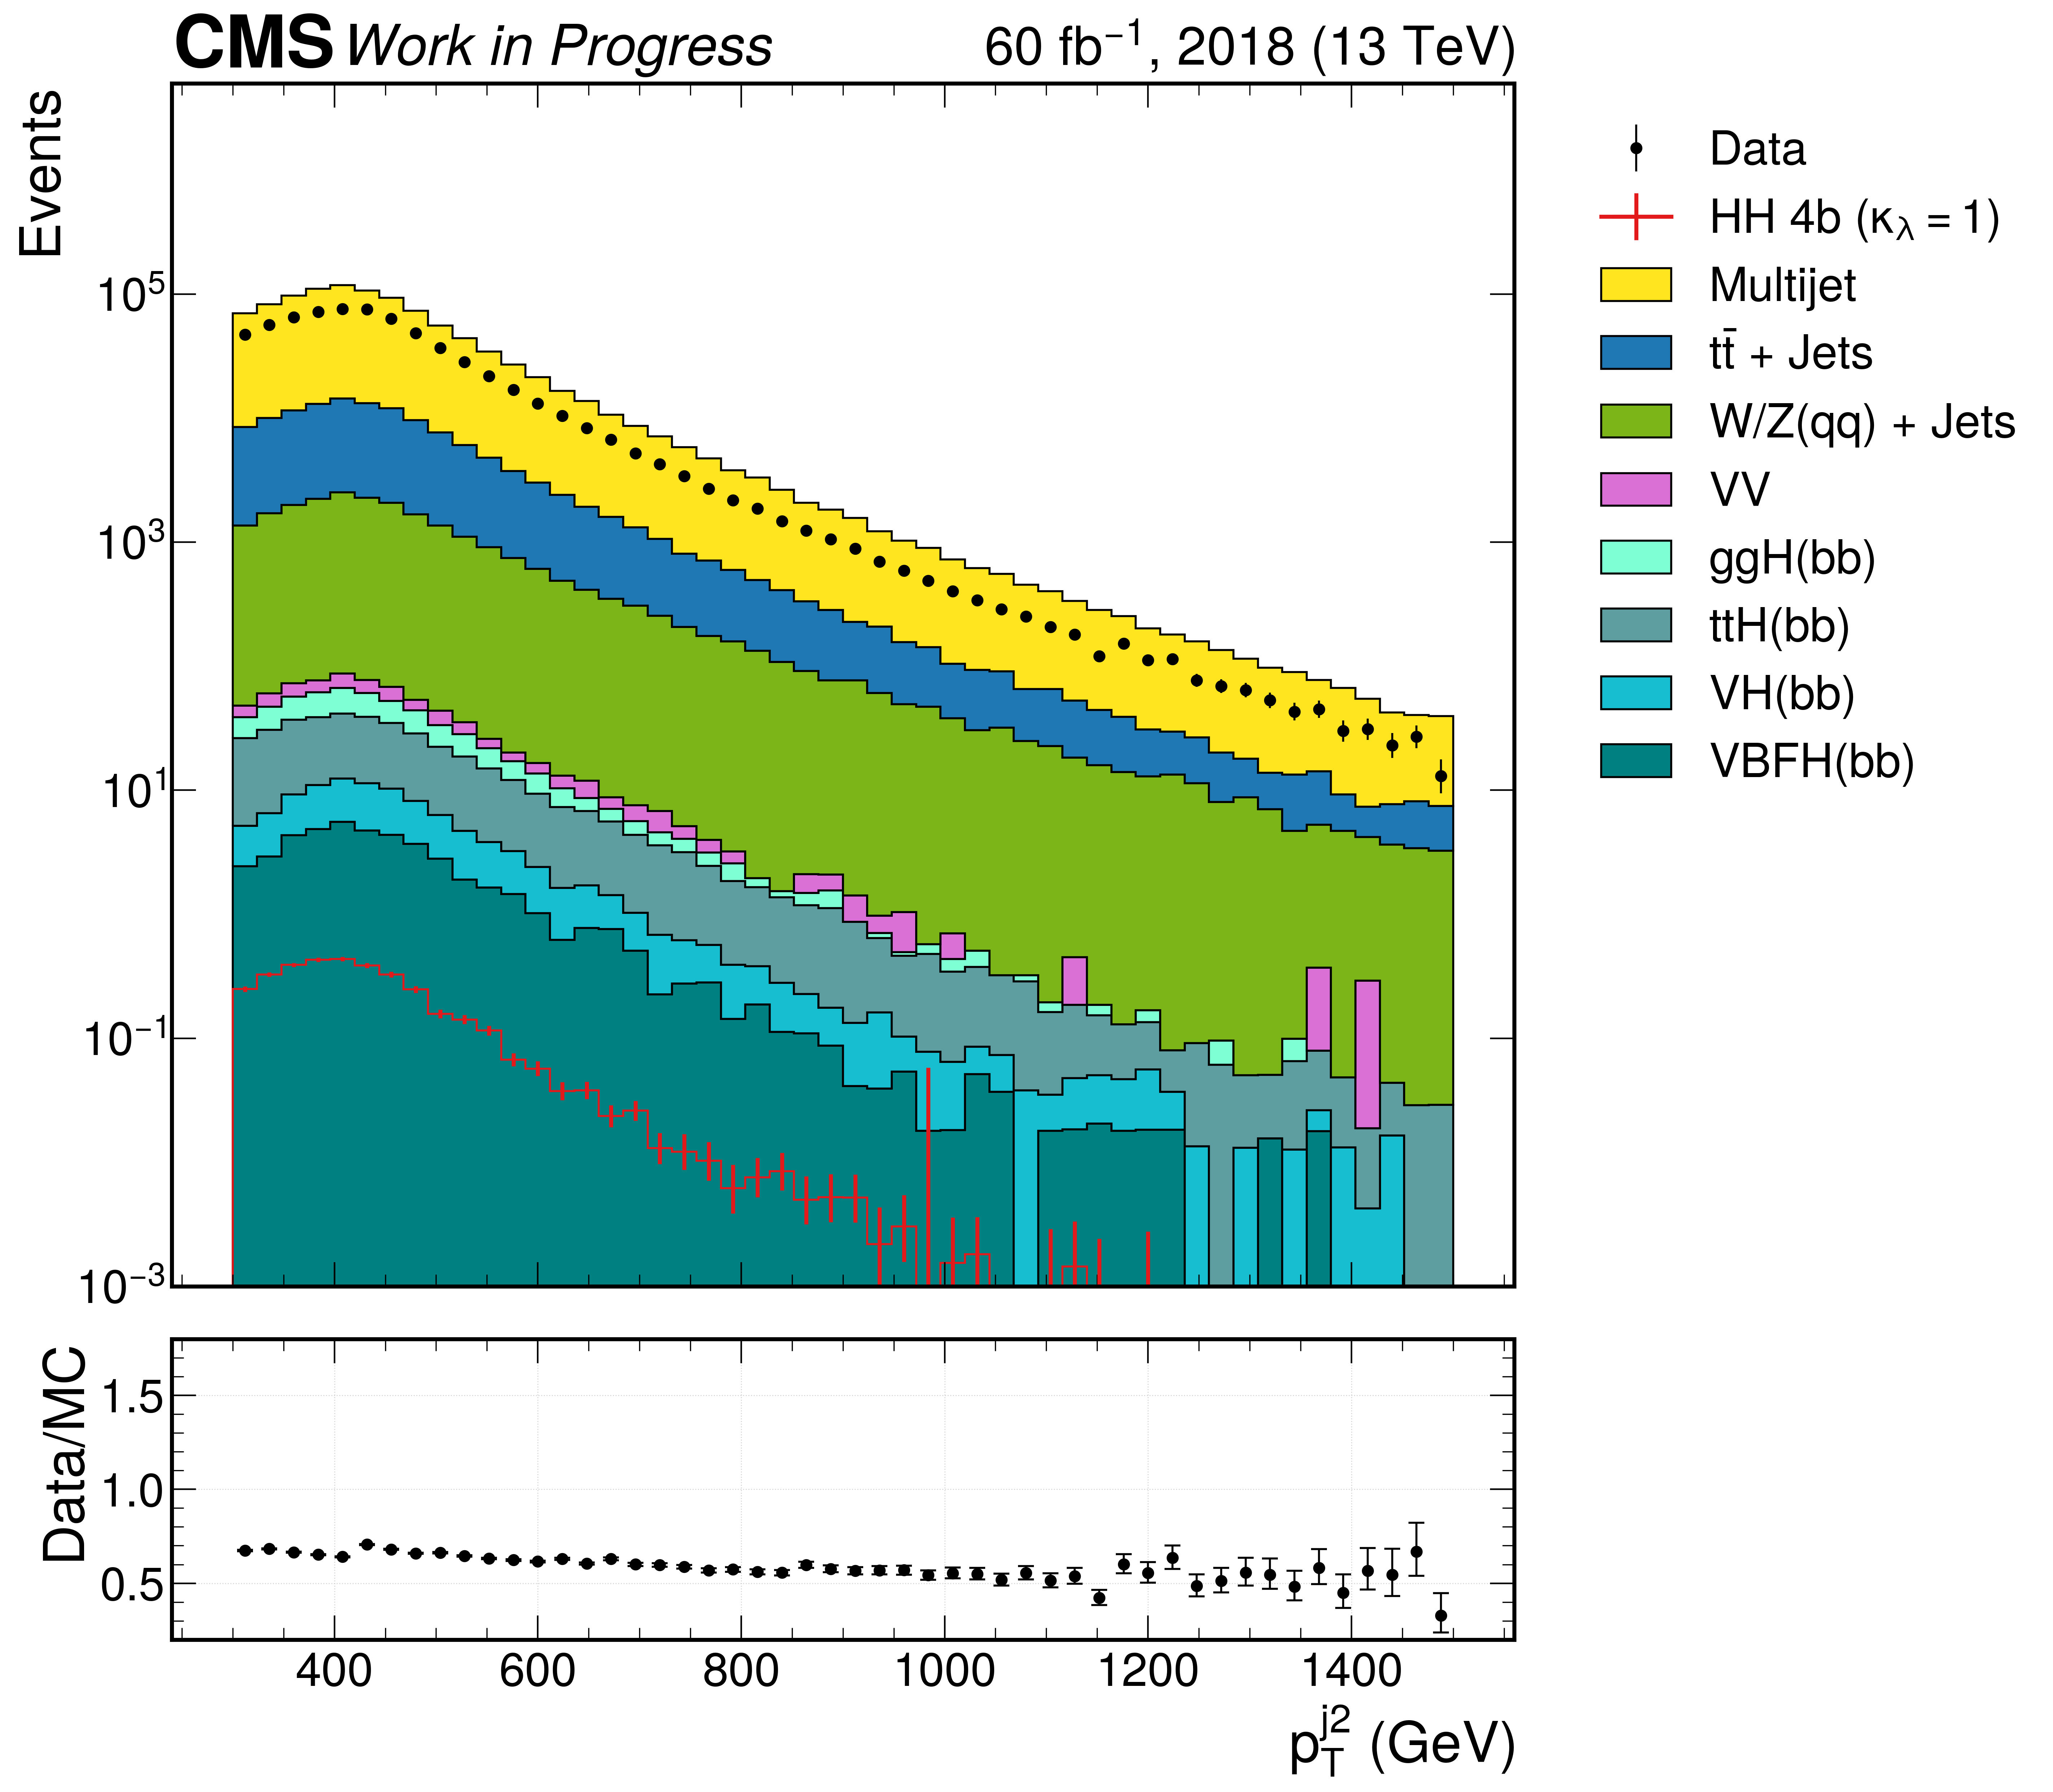

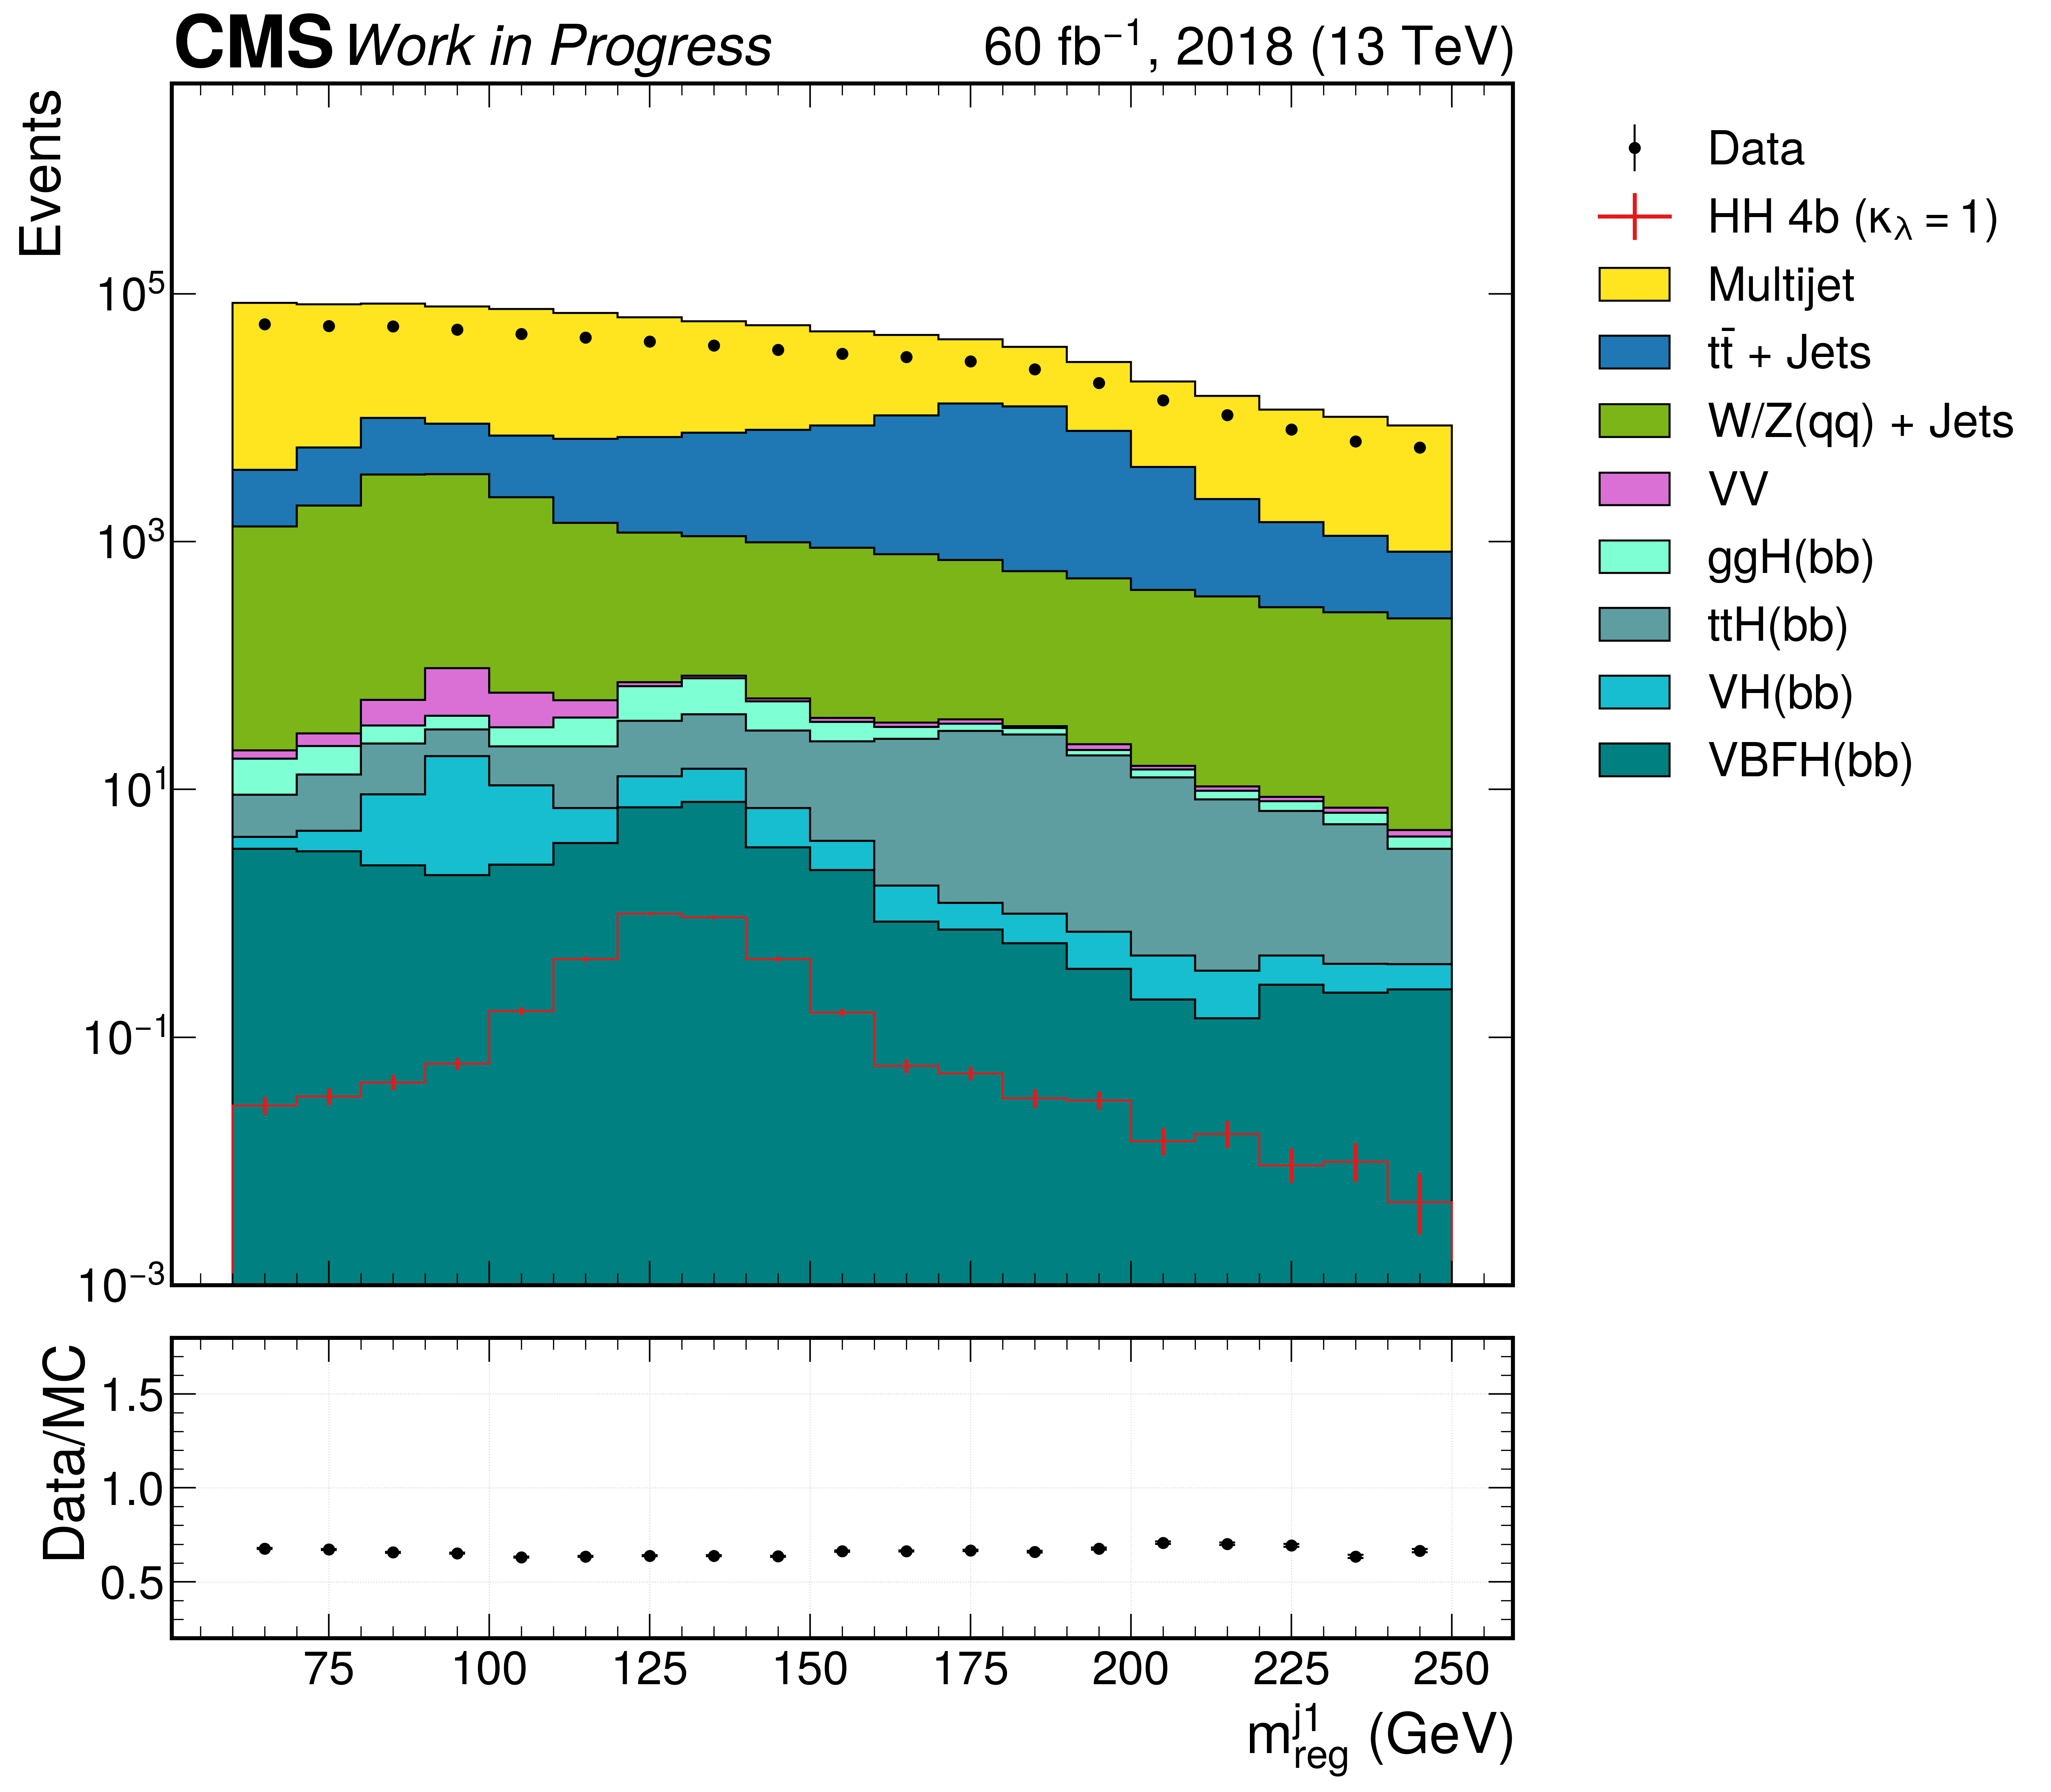

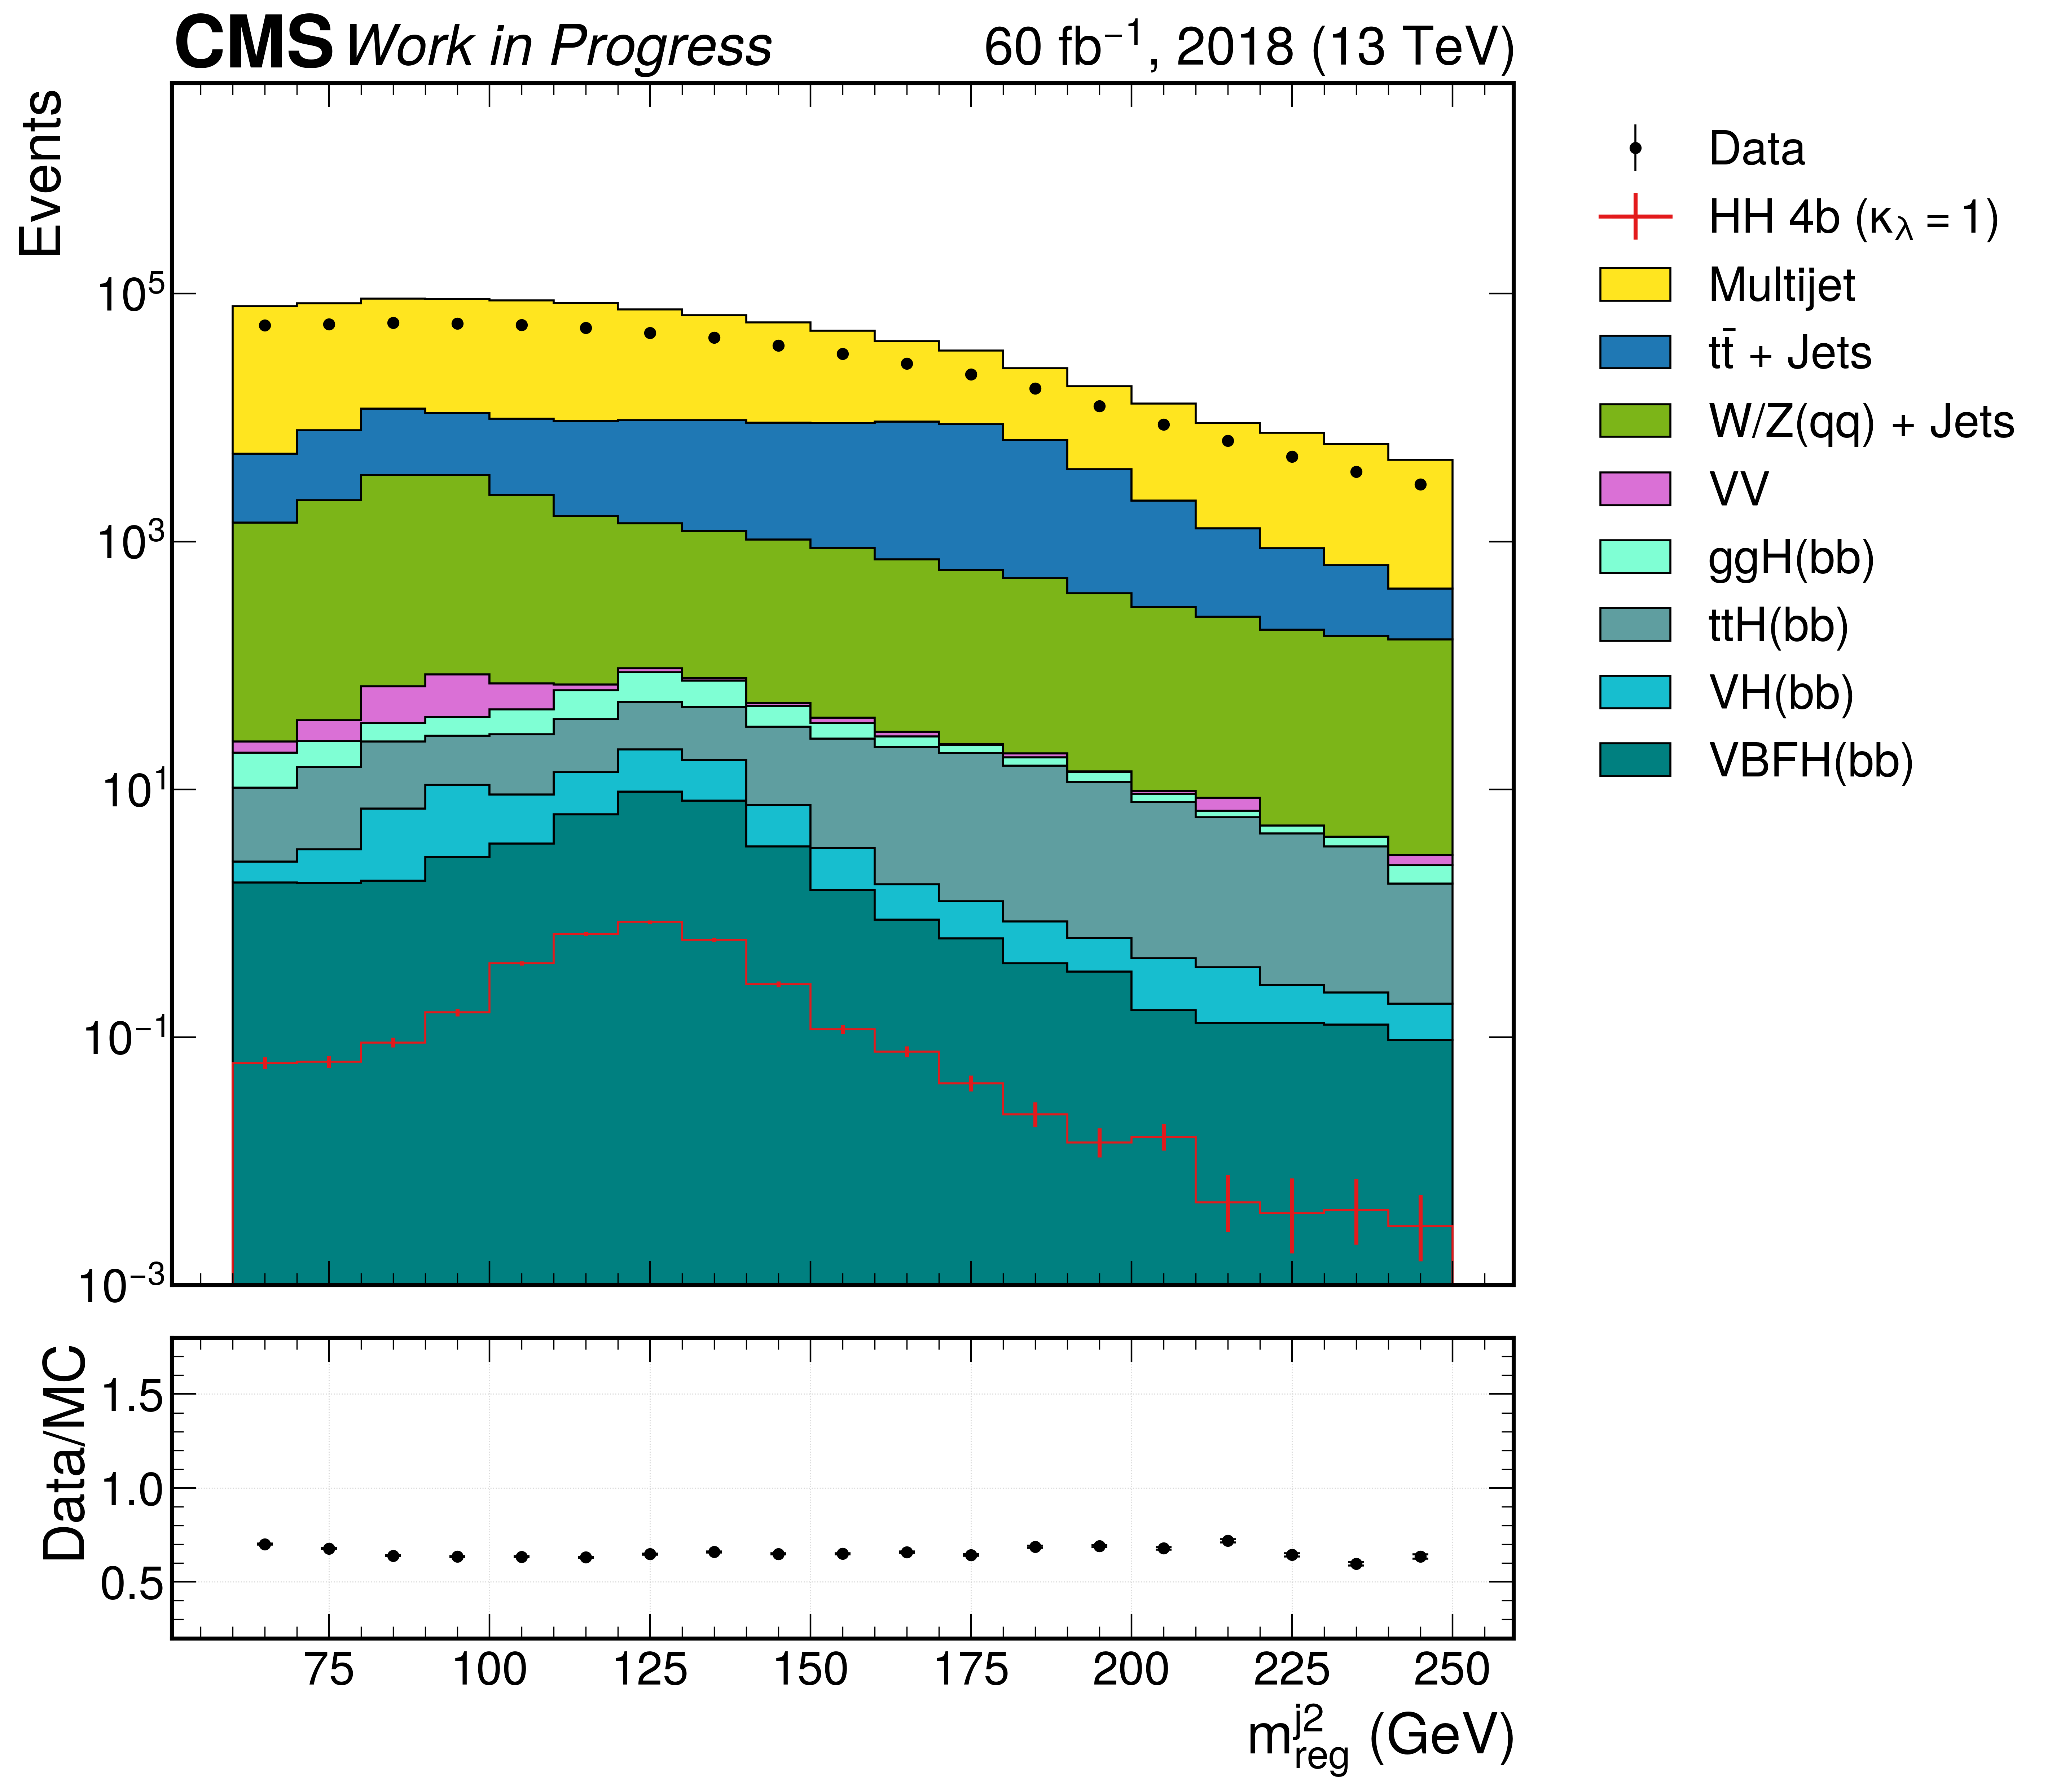

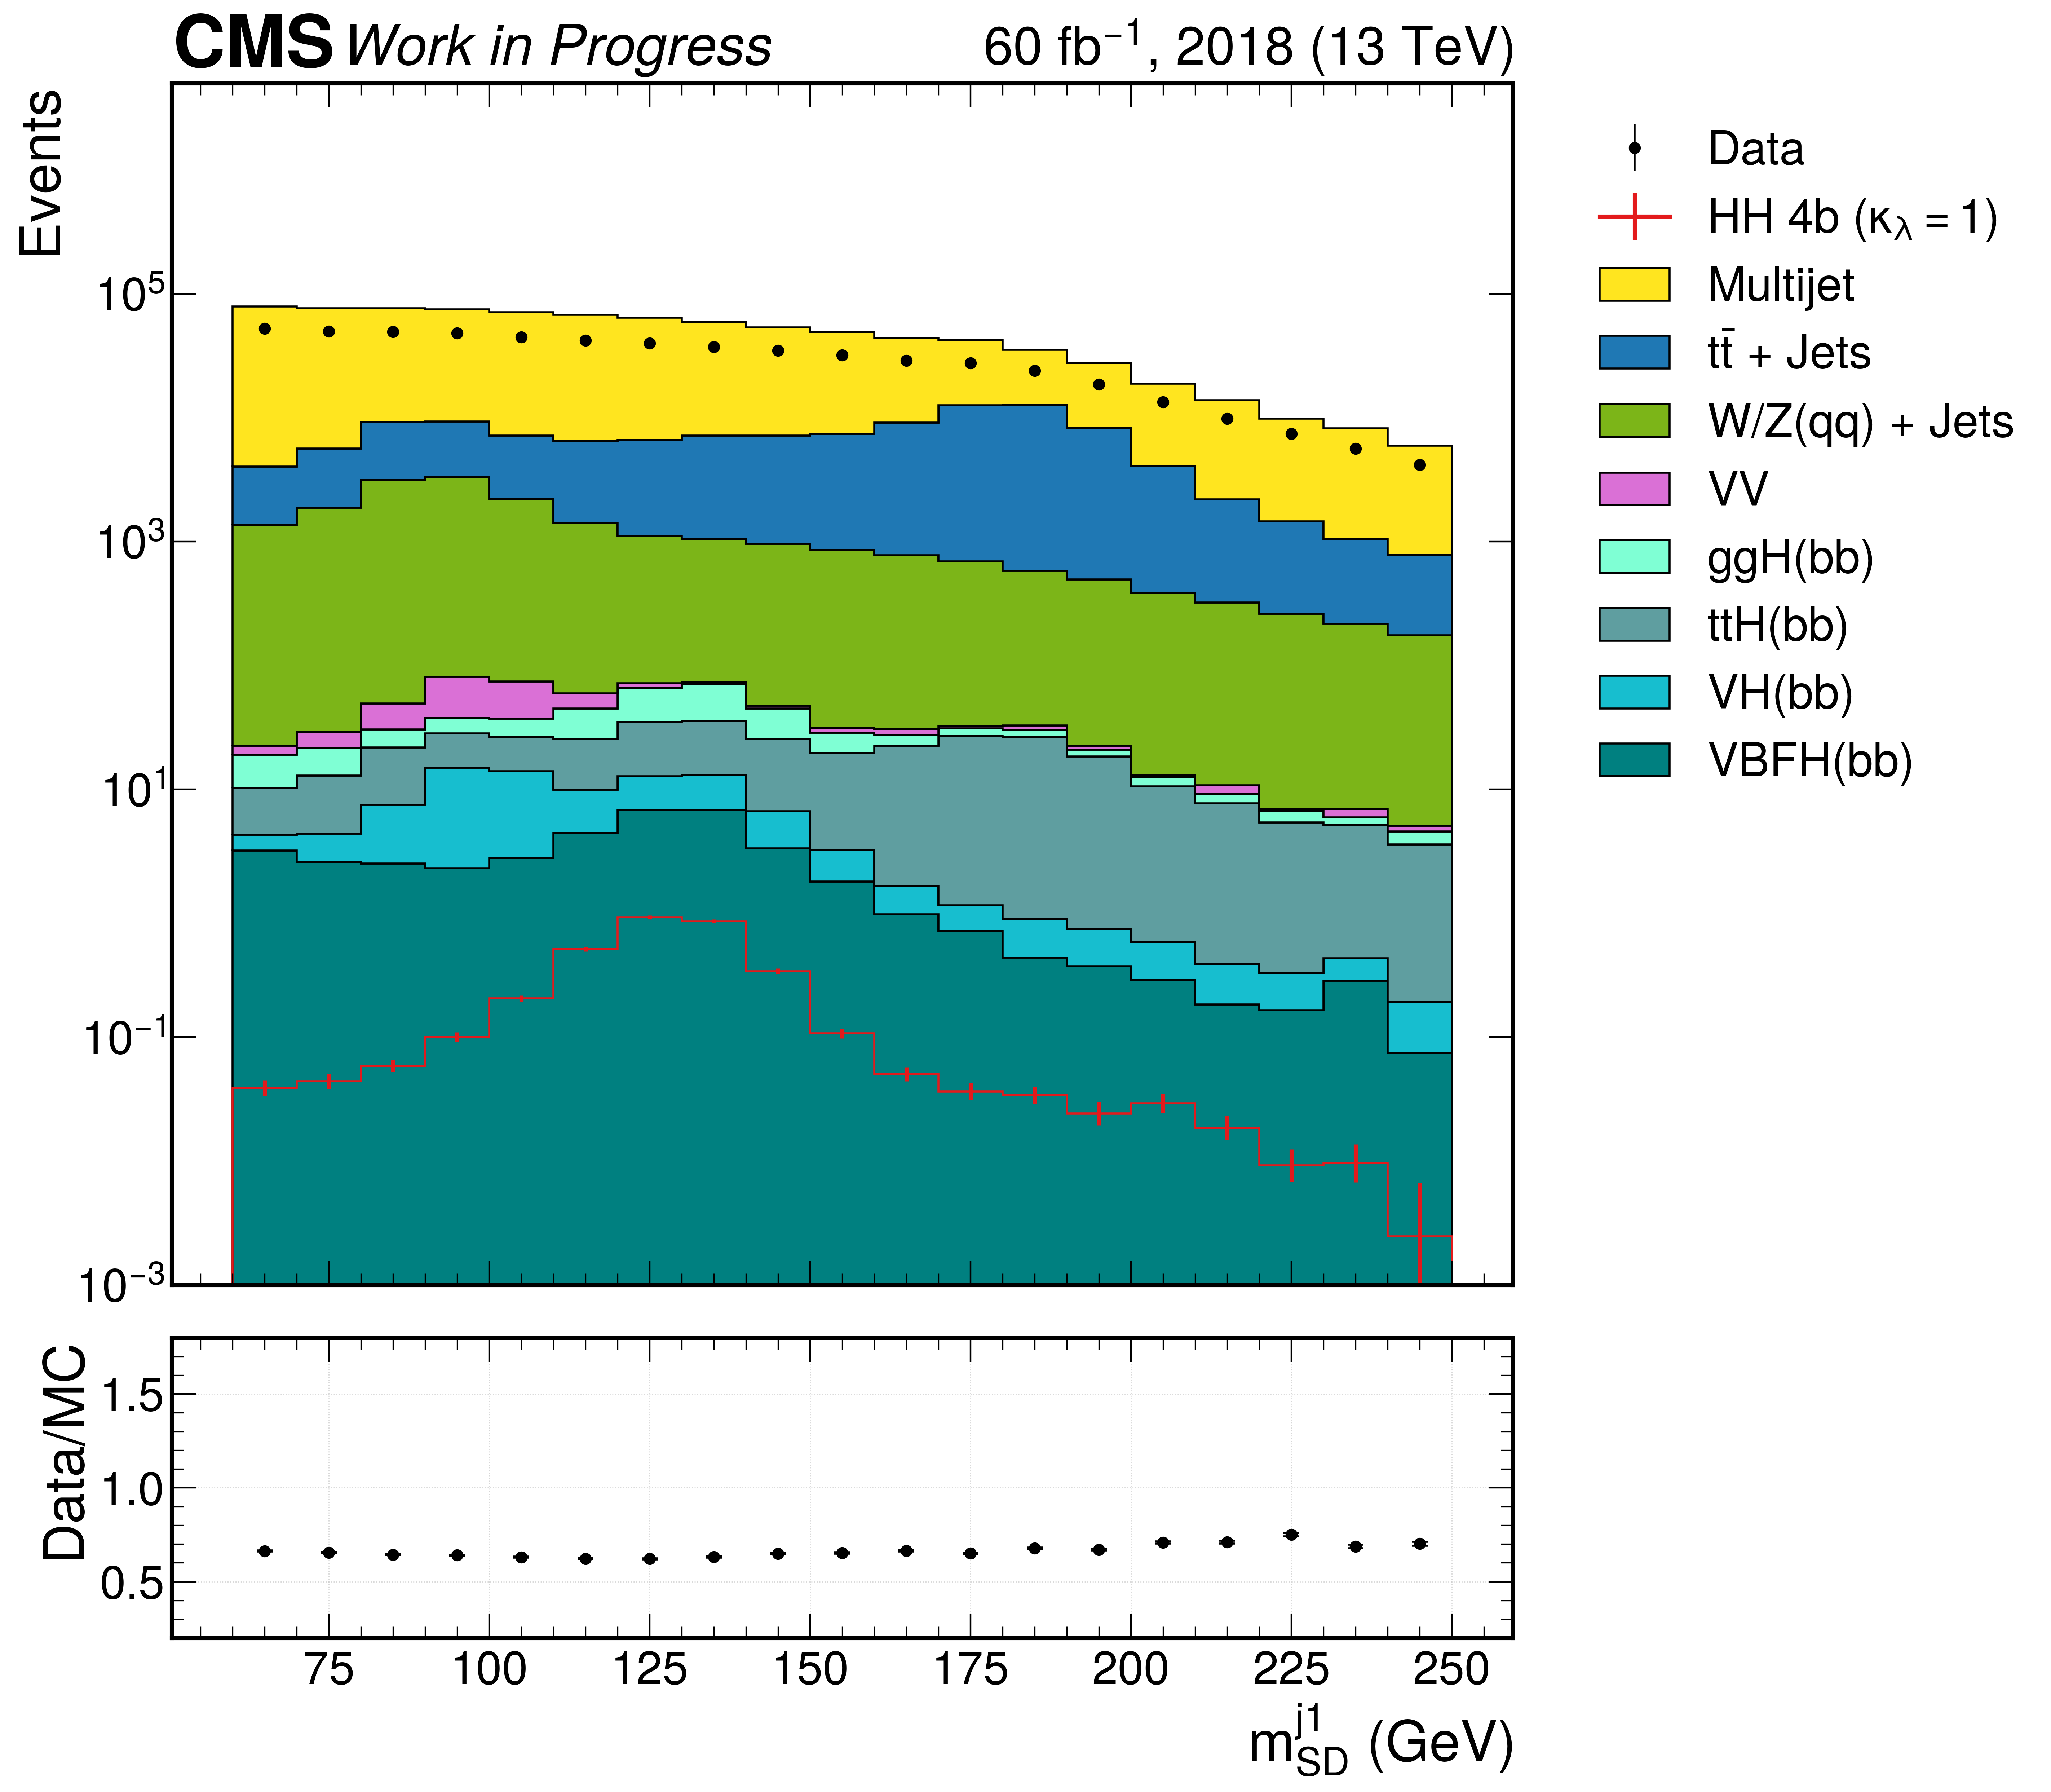

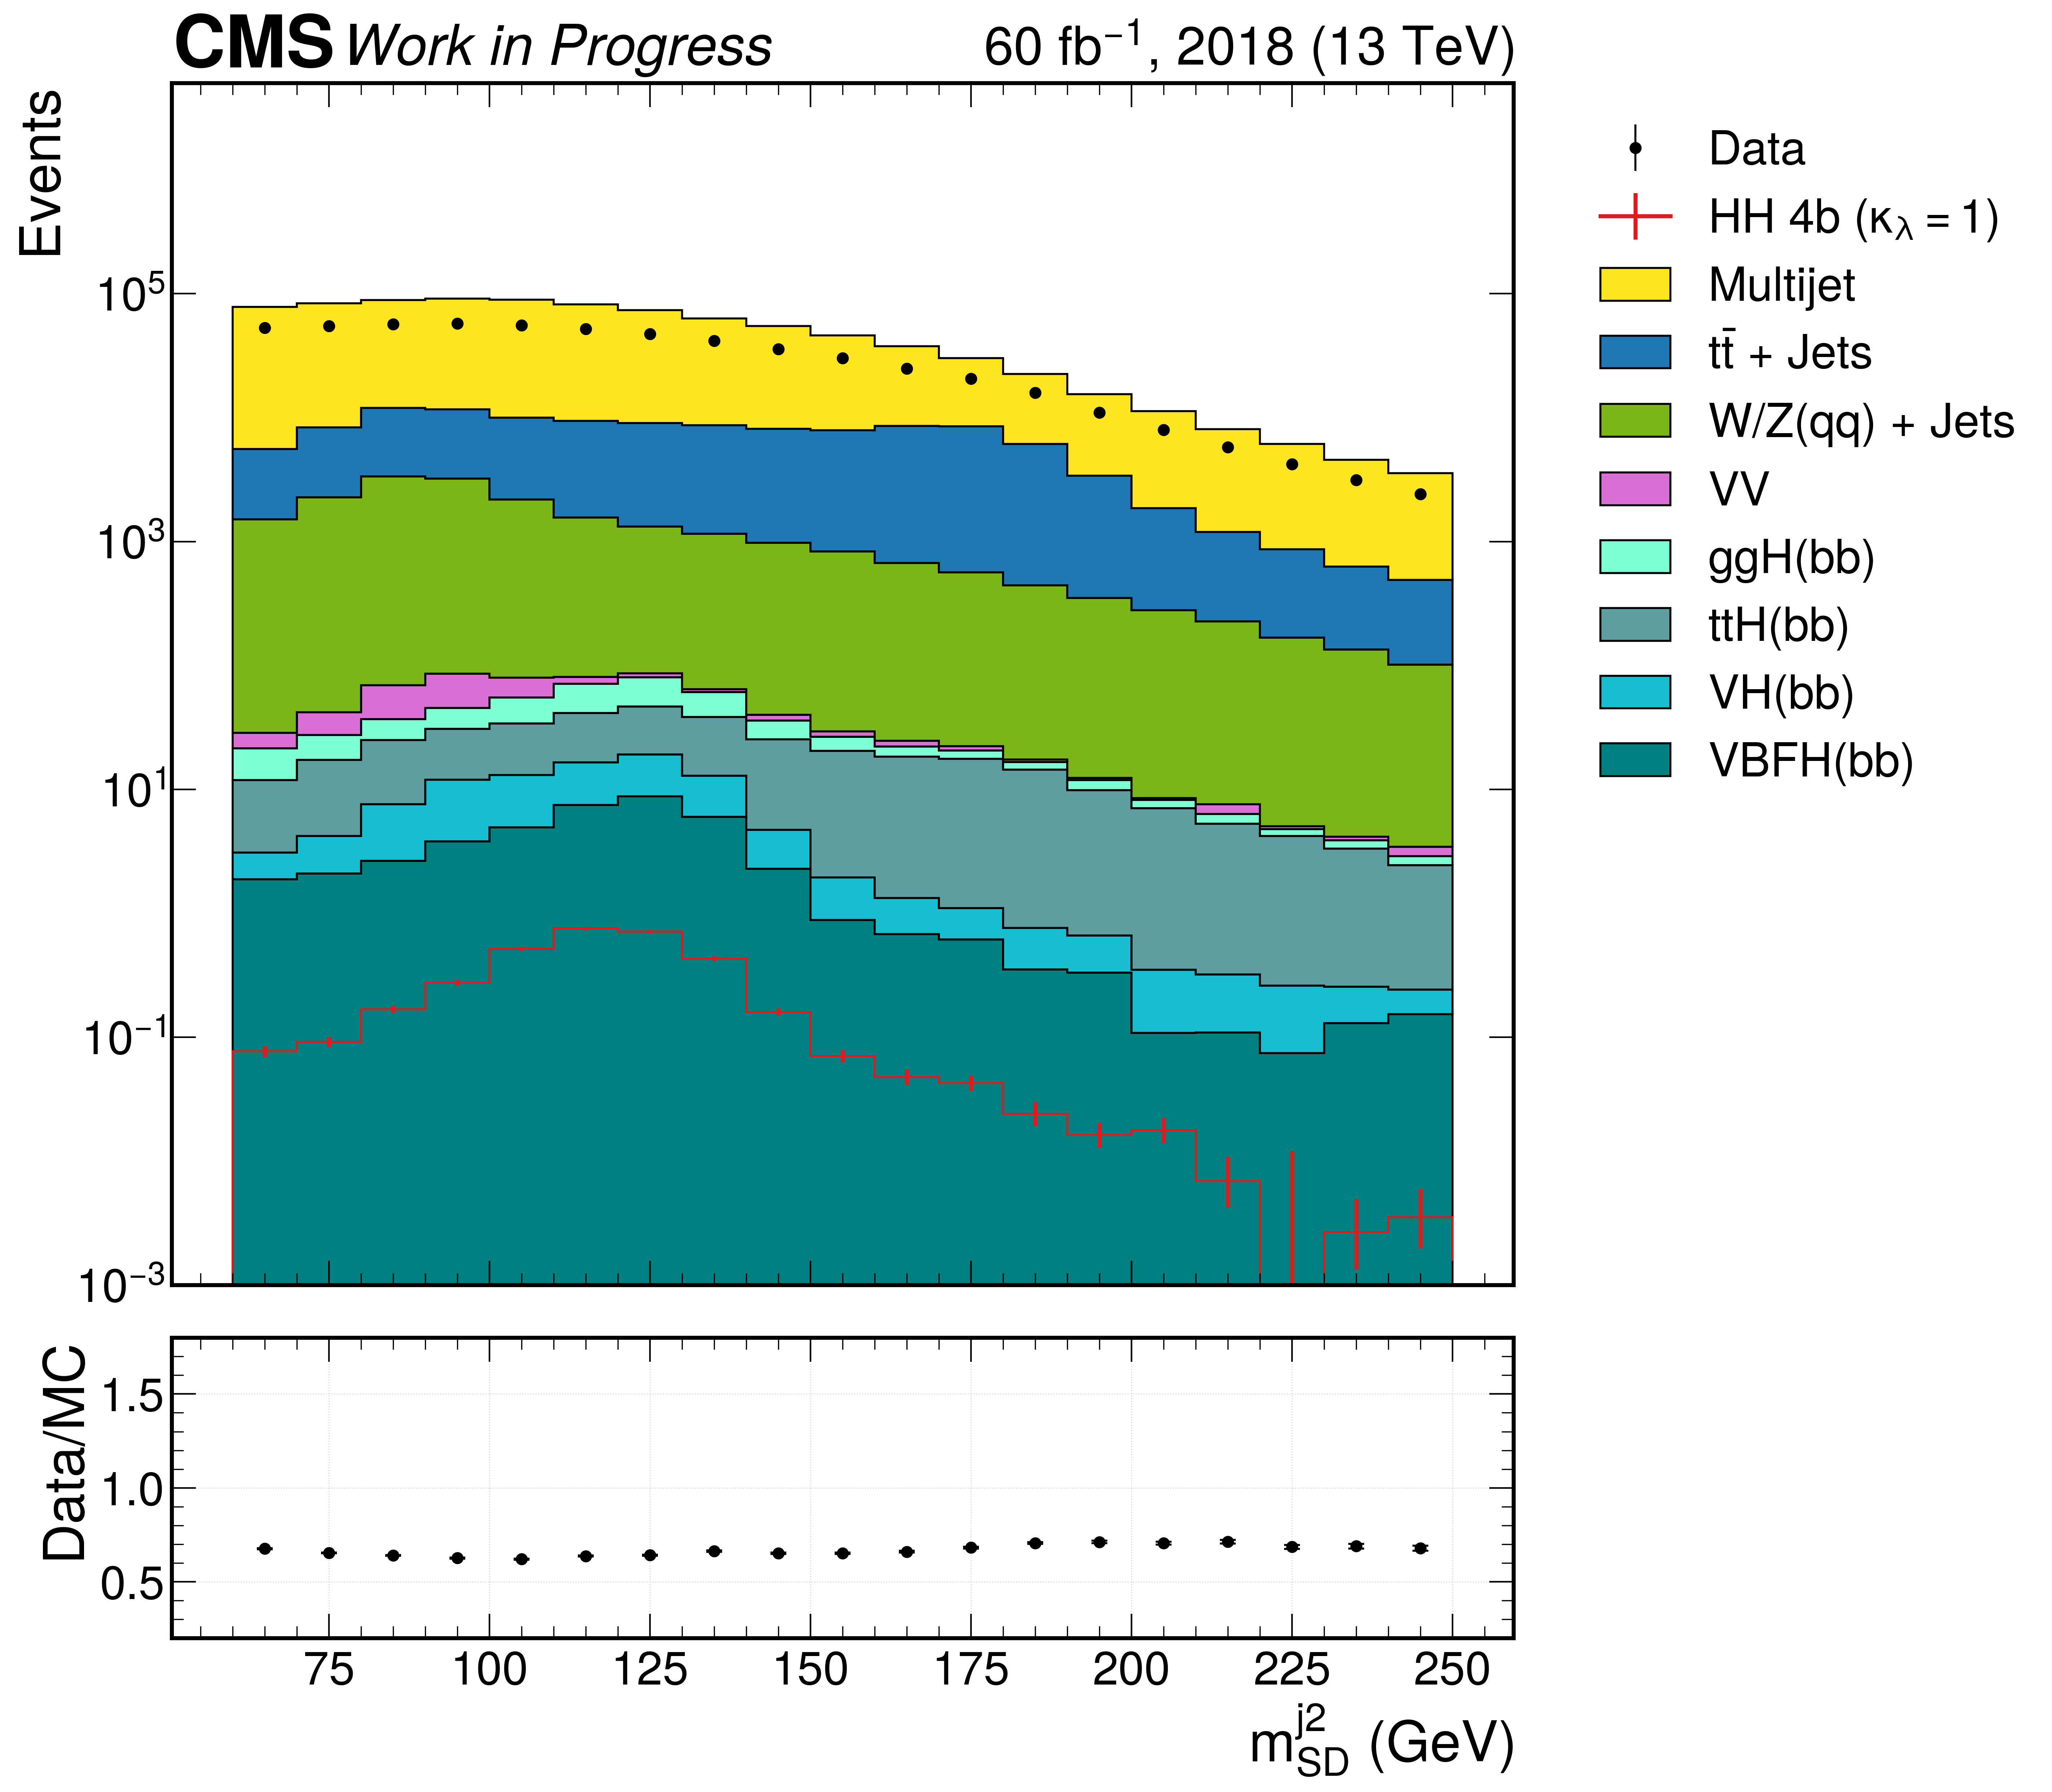

In [17]:
ylims = {
    "2018": 5e6,
    "2022": 1e5,
    "2022EE": 4e5,
}

# {var: (bins, label)}
control_plot_vars = [
    # var must match key in events dictionary (i.e. as saved in parquet file)
    # ShapeVar(var="DijetMass", label=r"$m^{jj}$ (GeV)", bins=[30, 600, 4000]),
    ShapeVar(var="ak8FatJetPt0", label=r"$p_T^{j1}$ (GeV)", bins=[50, 300, 1500]),
    ShapeVar(var="ak8FatJetPt1", label=r"$p_T^{j2}$ (GeV)", bins=[50, 300, 1500]),
    ShapeVar(
        var="ak8FatJetPNetMass0",
        label=r"$m_{reg}^{j1}$ (GeV)",
        bins=[19, 60, 250],
        significance_dir="bin",
    ),
    ShapeVar(
        var="ak8FatJetPNetMass1",
        label=r"$m_{reg}^{j2}$ (GeV)",
        bins=[19, 60, 250],
        significance_dir="bin",
    ),
    ShapeVar(
        var="ak8FatJetMsd0",
        label=r"$m_{SD}^{j1}$ (GeV)",
        bins=[19, 60, 250],
        significance_dir="bin",
    ),
    ShapeVar(
        var="ak8FatJetMsd1",
        label=r"$m_{SD}^{j2}$ (GeV)",
        bins=[19, 60, 250],
        significance_dir="bin",
    ),
    # ShapeVar(
    #     var="ak8FatJetPNetXbb0",
    #     label=r"$T_{Xbb}^{j1}$",
    #     bins=[50, 0.0, 1],
    # ),
    # ShapeVar(
    #     var="ak8FatJetPNetXbb1",
    #     label=r"$T_{Xbb}^{j2}$",
    #     bins=[50, 0.0, 1],
    # ),
    # ShapeVar(
    #     var="ht",
    #     label=r"HT (GeV)",
    #     bins=[50, 0, 4000],
    # ),
]

hists = {}
for shape_var in control_plot_vars:
    if shape_var.var not in hists:
        hists[shape_var.var] = utils.singleVarHist(
            events_dict,
            shape_var,
            weight_key="weight",
        )

sig_keys = ["hh4b"]
for shape_var in control_plot_vars:
    name = f"{plot_dir}/{shape_var.var}.pdf"
    plotting.ratioHistPlot(
        hists[shape_var.var],
        year,
        sig_keys,
        bg_keys,
        name=name,
        show=True,
        log=True,
        plot_significance=False,
        significance_dir=shape_var.significance_dir,
        ratio_ylims=[0.2, 1.8],
        ylim=ylims[year],
        energy="13",
    )
    # break

mSD vs mReg

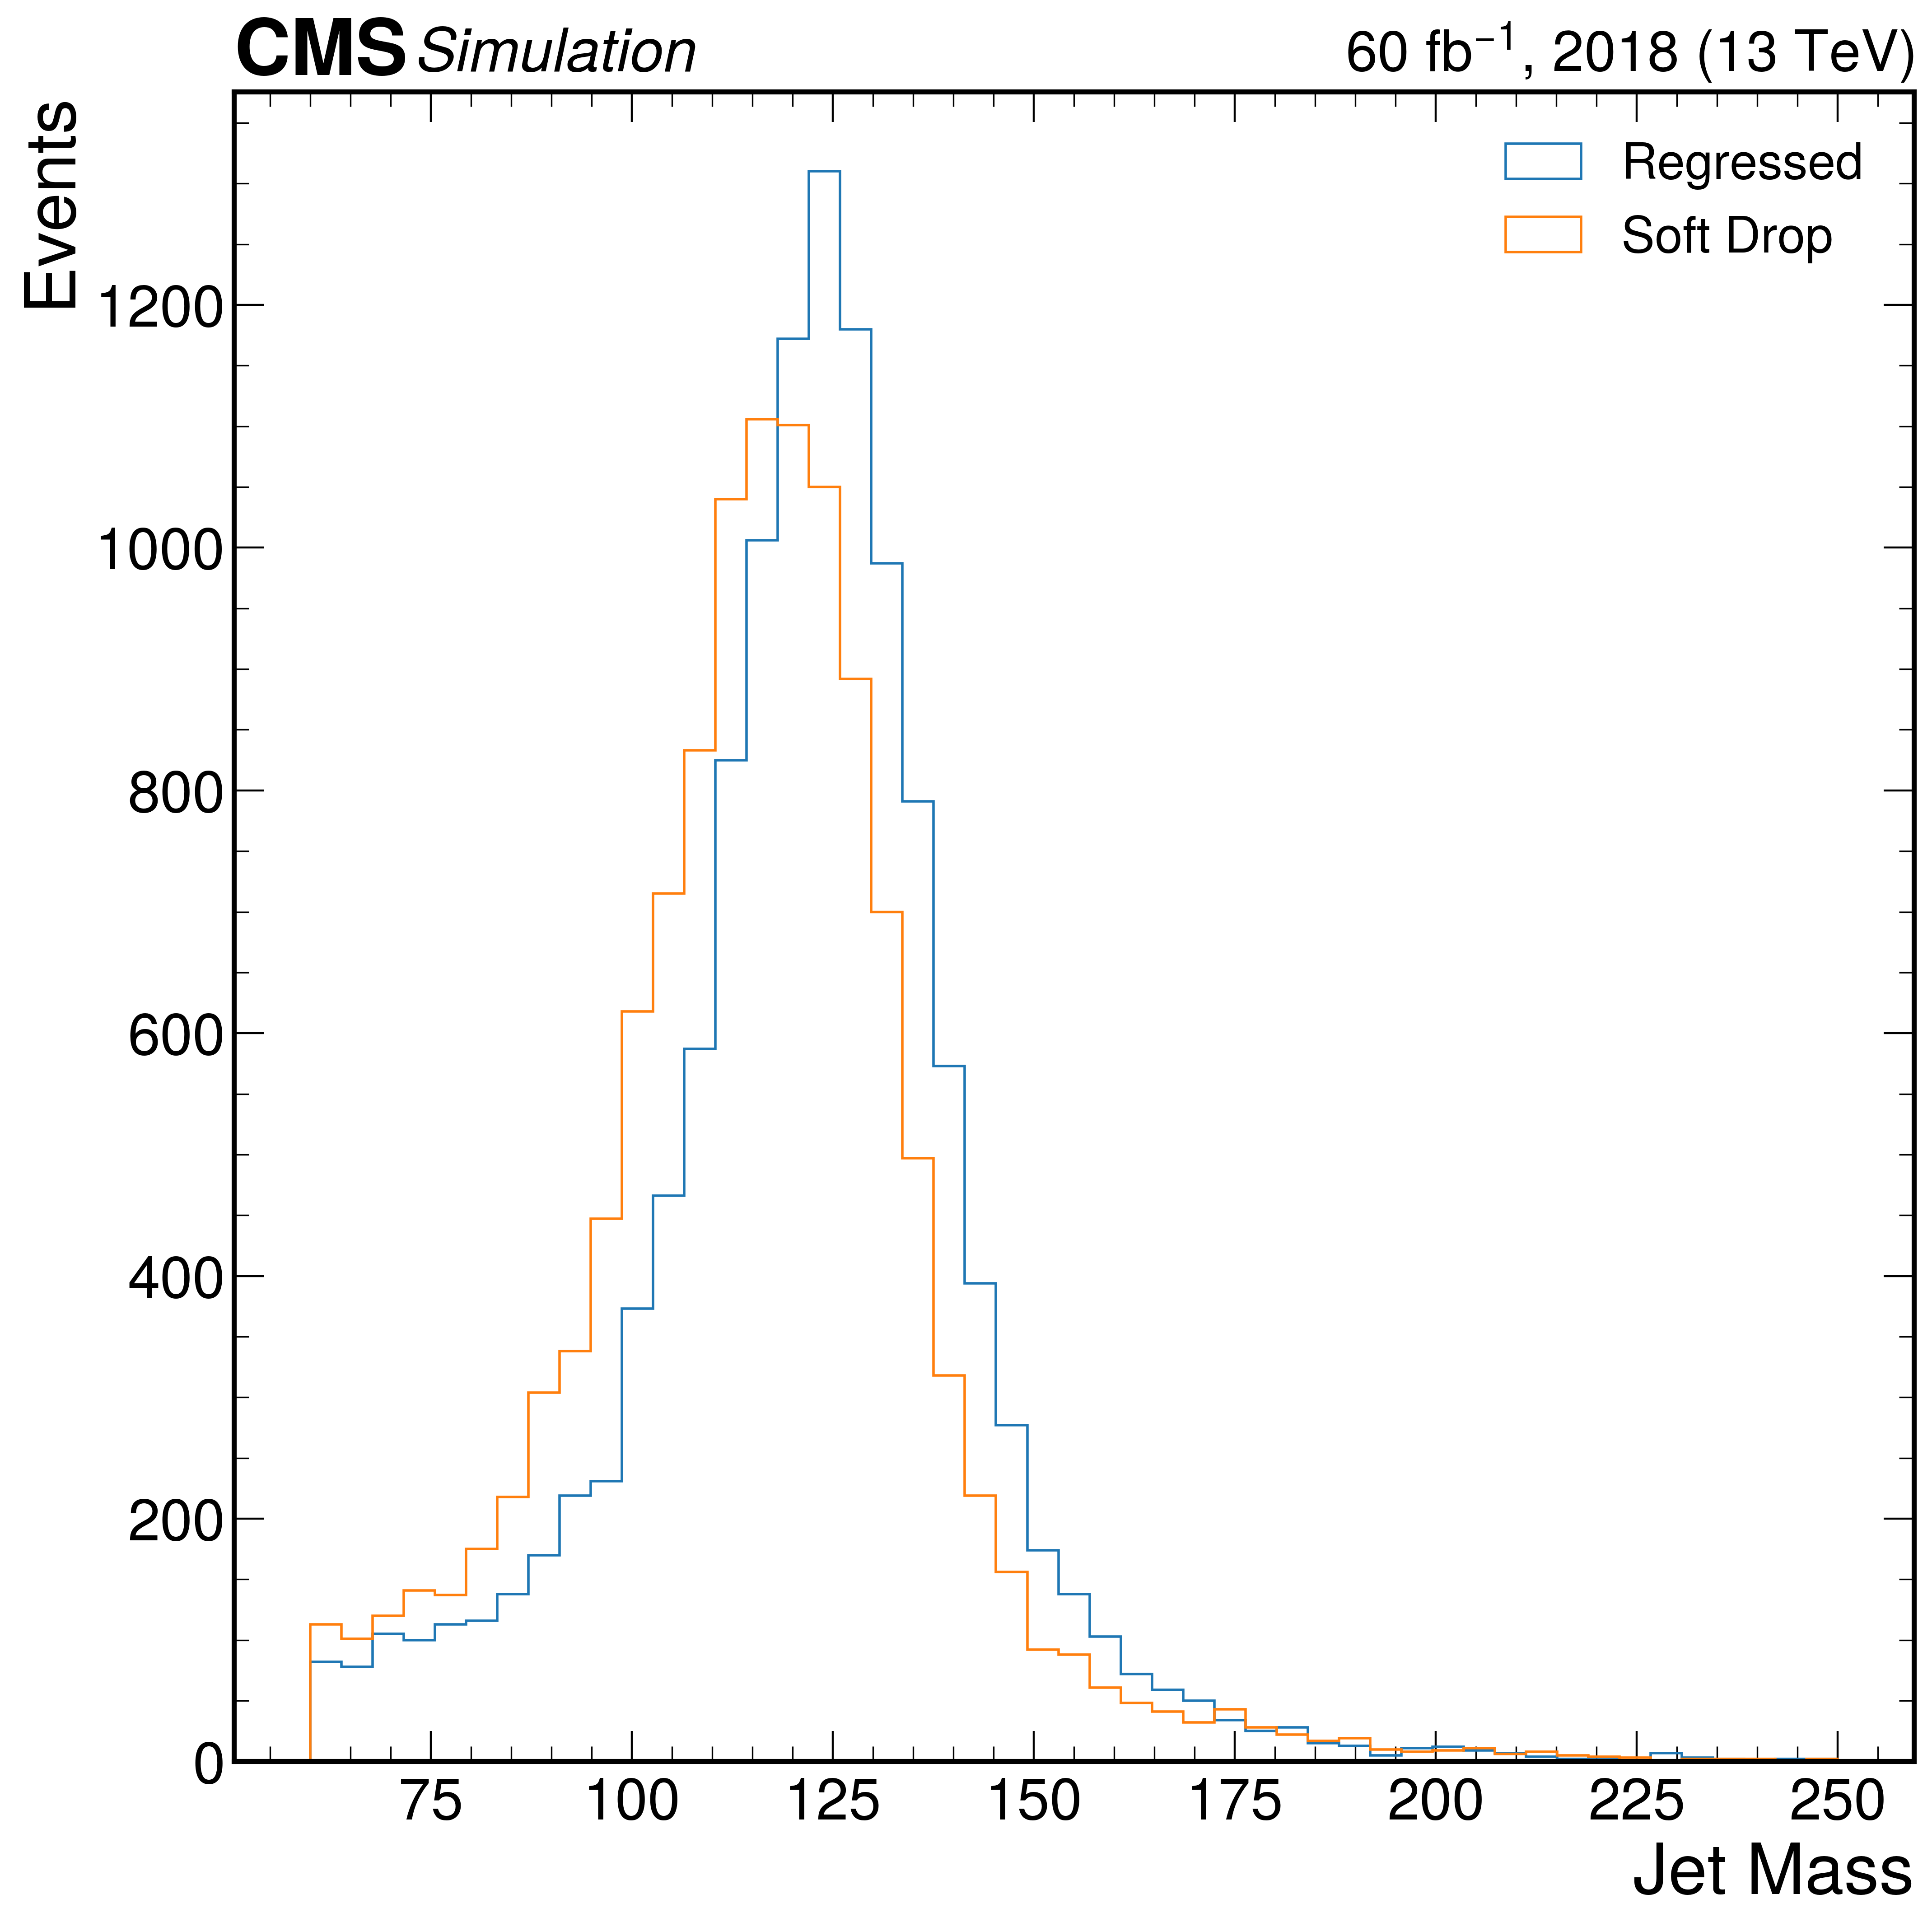

In [18]:
events = events_dict["hh4b"]

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
plt.rcParams.update({"font.size": 24})

bins = np.linspace(60, 250, 50)

ax.hist(
    events["ak8FatJetPNetMass"][1],
    bins=bins,
    histtype="step",
    label="Regressed",
)

ax.hist(
    events["ak8FatJetMsd"][1],
    bins=bins,
    histtype="step",
    label="Soft Drop",
)

ax.set_xlabel("Jet Mass")
ax.set_ylabel("Events")

hep.cms.label(data=False, year=year, lumi=round(LUMI[year] / 1e3), com="13")

ax.legend()
plt.savefig(f"{plot_dir}/msd_mreg.pdf", bbox_inches="tight")
plt.show()

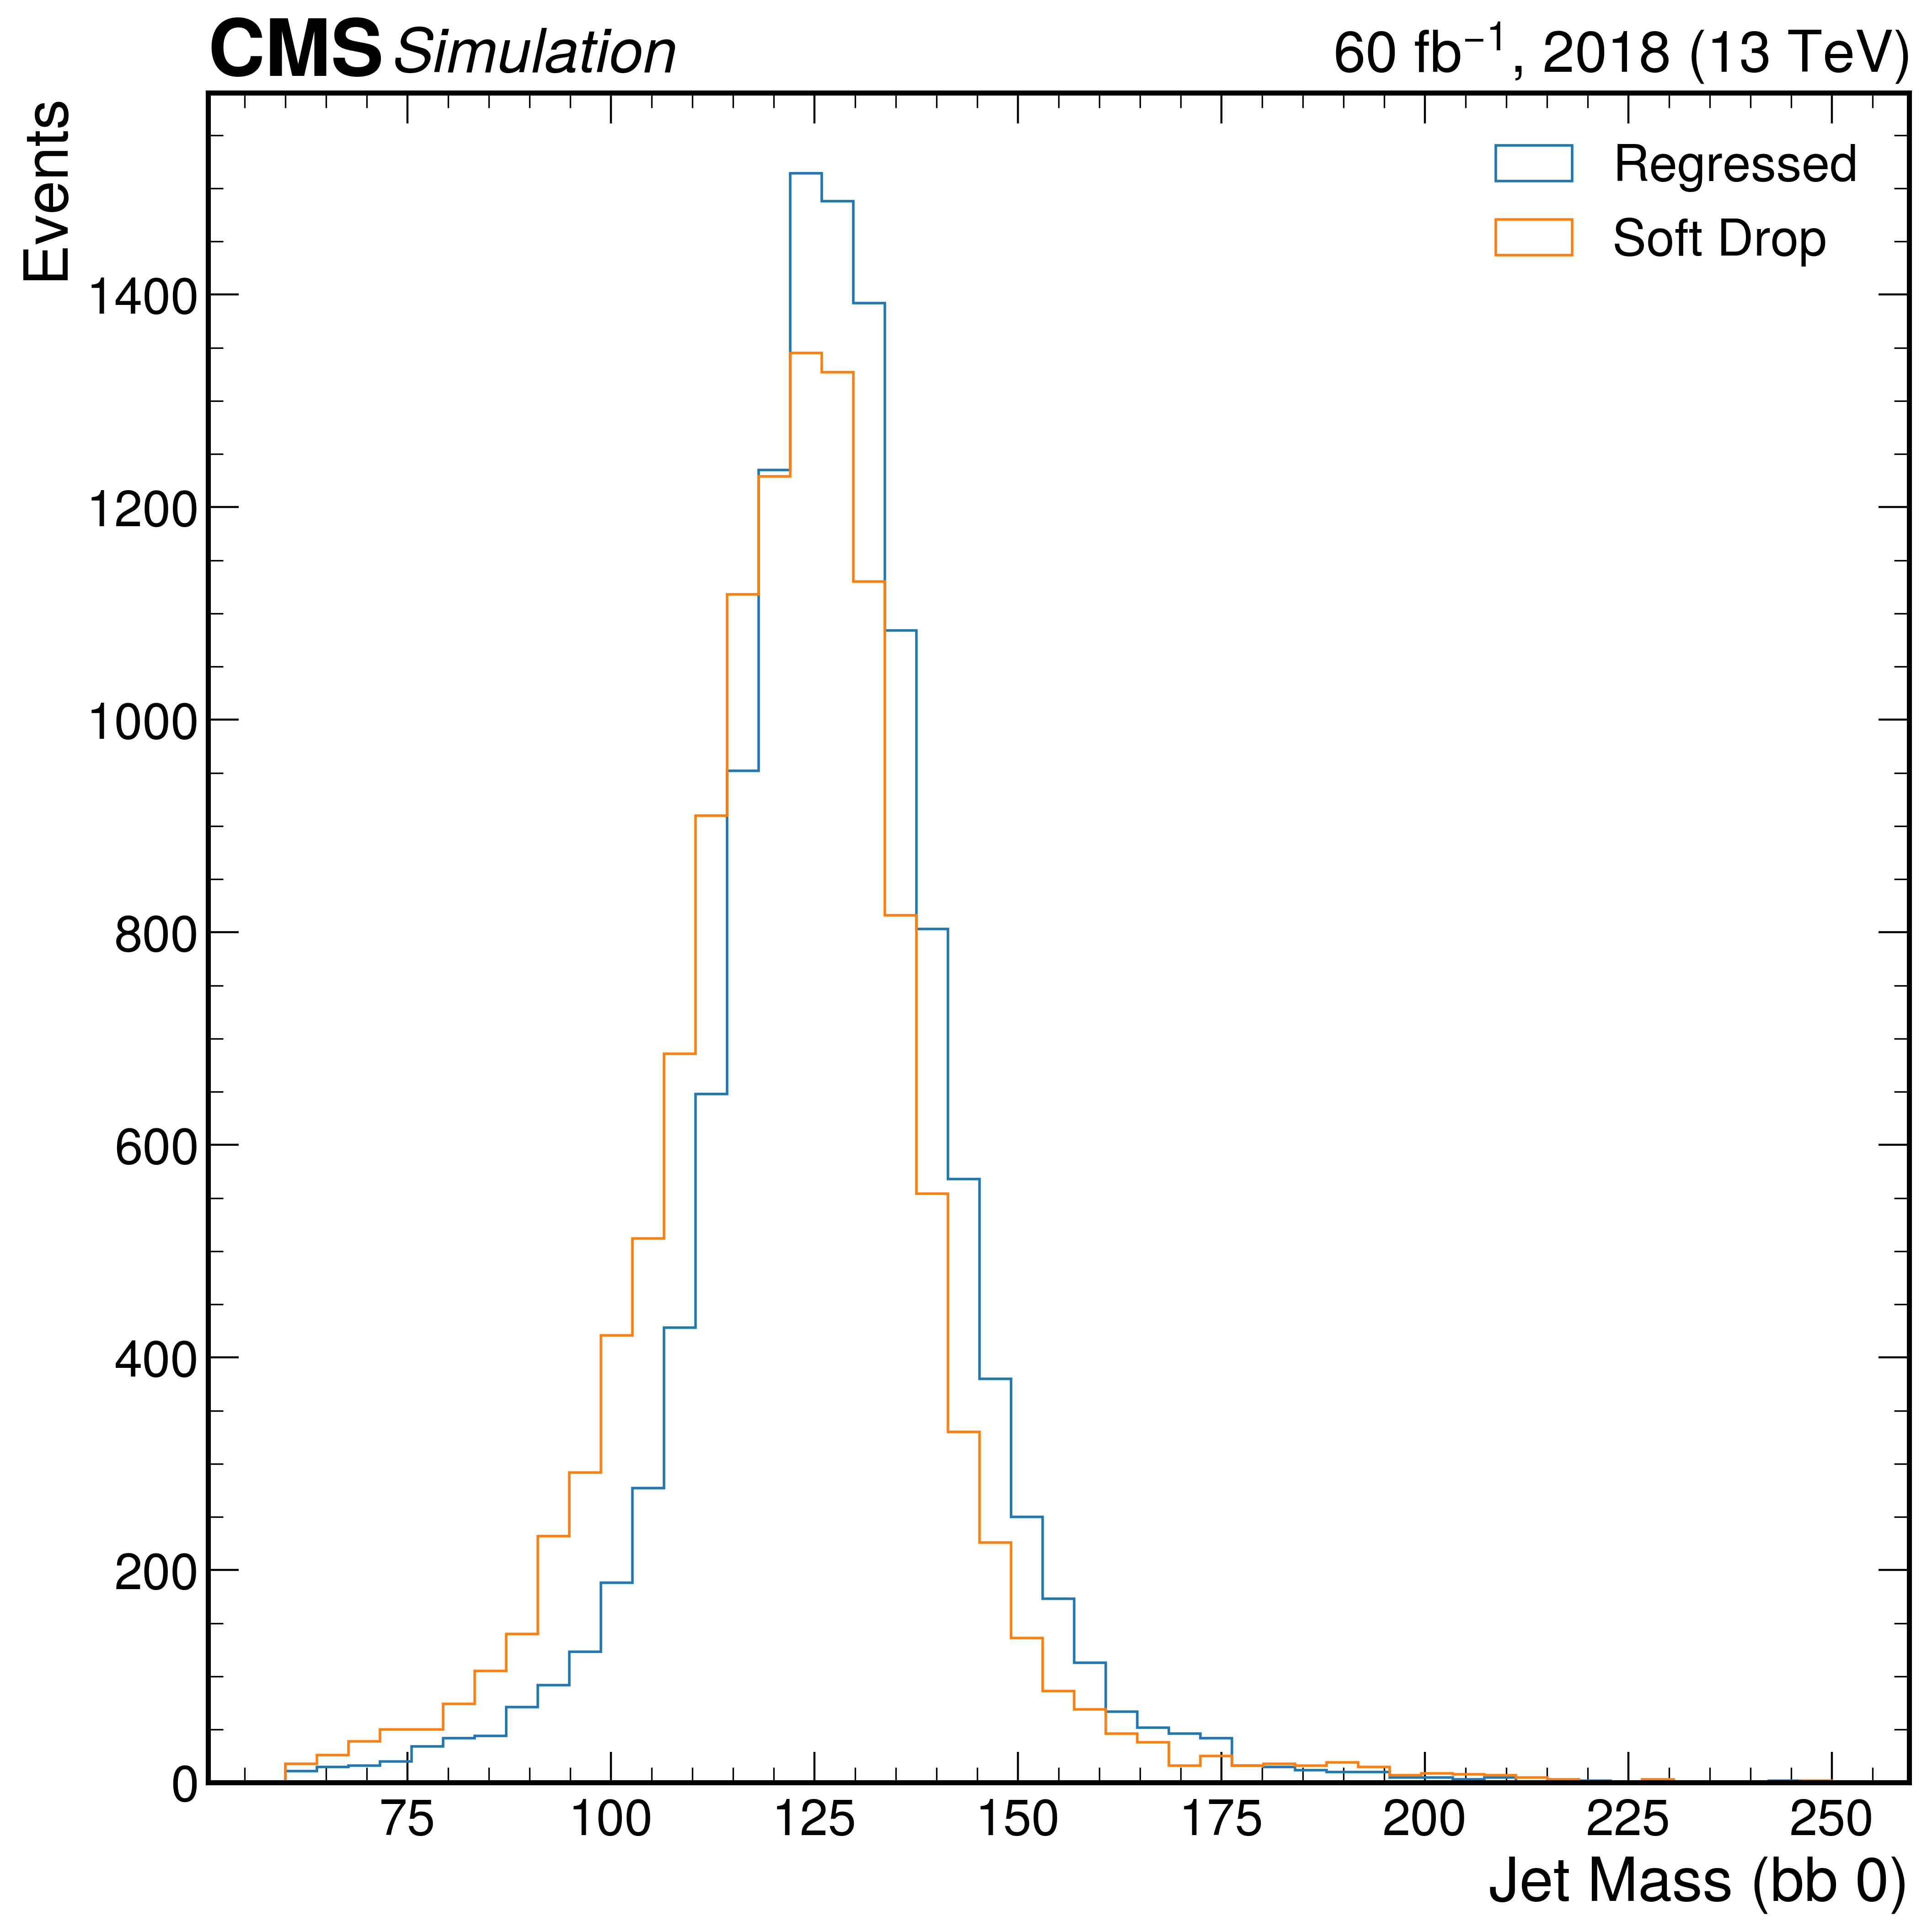

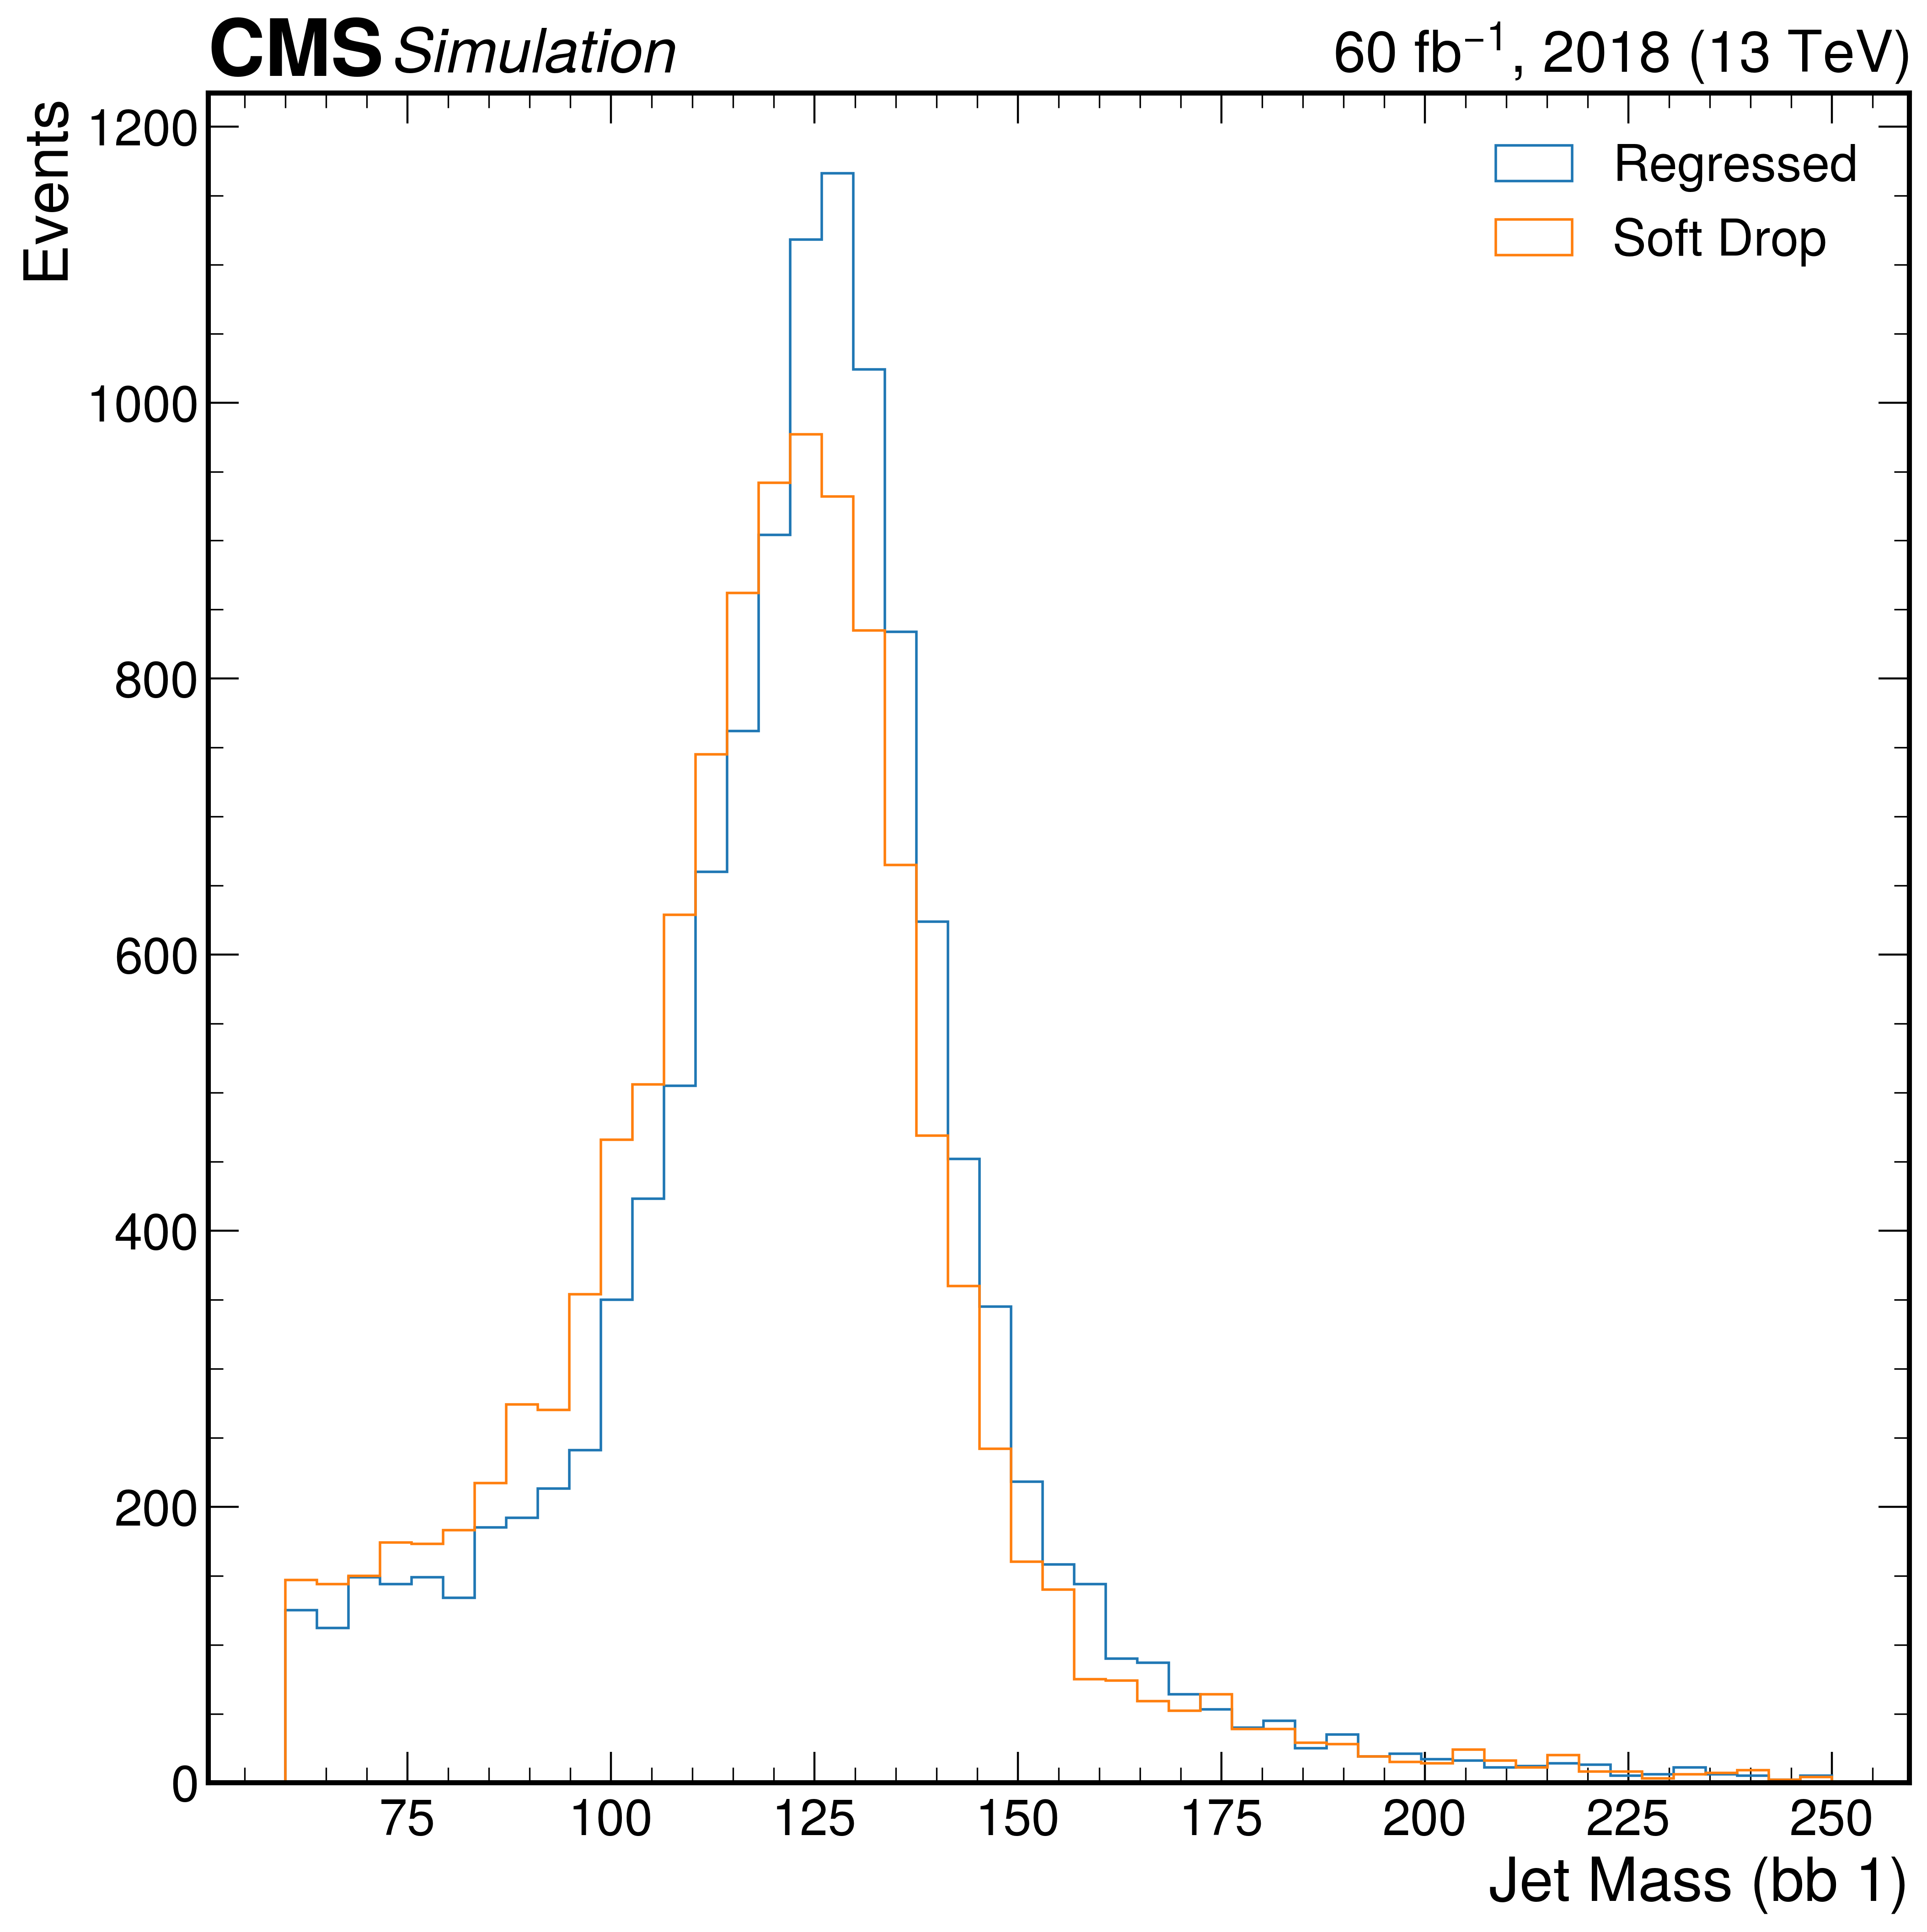

In [19]:
events = events_dict["hh4b"]

for i in range(2):
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    plt.rcParams.update({"font.size": 24})
    bins = np.linspace(60, 250, 50)
    ax.hist(
        utils.get_feat(events, f"bb{i}FatJetPNetMass", bb_masks["hh4b"]),
        bins=bins,
        histtype="step",
        label="Regressed",
    )
    ax.hist(
        utils.get_feat(events, f"bb{i}FatJetMsd", bb_masks["hh4b"]),
        bins=bins,
        histtype="step",
        label="Soft Drop",
    )
    ax.set_xlabel(f"Jet Mass (bb {i})")
    ax.set_ylabel("Events")
    hep.cms.label(data=False, year=year, lumi=round(LUMI[year] / 1e3), com="13")
    ax.legend()
    plt.savefig(f"{plot_dir}/msd_mreg_bb{i}.pdf", bbox_inches="tight")
    plt.show()

## ROC Curve

Get true Higgses

In [20]:
events = events_dict["hh4b"]

indexak8 = events["ak8FatJetHiggsMatchIndex"].to_numpy()
nbh1ak8 = events["ak8FatJetNumBMatchedH1"].to_numpy()
nbh2ak8 = events["ak8FatJetNumBMatchedH2"].to_numpy()

# ak8 jets matched to h1 and h2
h1ak8 = indexak8 == 0
h2ak8 = indexak8 == 1
num_ak8m2h1 = h1ak8.sum(axis=1)
num_ak8m2h2 = h2ak8.sum(axis=1)
h1m1ak8 = num_ak8m2h1 == 1
h2m1ak8 = num_ak8m2h2 == 1

# ak8 jets matched to 2 b-quarks
h1ak8nb2 = (indexak8 == 0) & (nbh1ak8 == 2)
h2ak8nb2 = (indexak8 == 1) & (nbh2ak8 == 2)
h1m1ak8b2 = h1ak8nb2.sum(axis=1) == 1
h2m1ak8b2 = h2ak8nb2.sum(axis=1) == 1
boosted_nb2 = h1m1ak8b2 & h2m1ak8b2

# fatjet matched to H1
fj_mwh1_idx = events["ak8FatJetHiggsMatchIndex"].to_numpy() == 0
fj_score = events["ak8FatJetPNetXbb"].to_numpy()
sig_jets_score = fj_score[boosted_nb2][fj_mwh1_idx[boosted_nb2]]
sig_jets_score.shape

sig_jets_score = fj_score[fj_mwh1_idx]
sig_jets_score.shape

(11849,)

In [21]:
bg_jets_score = events_dict["qcd"]["ak8FatJetPNetXbb"].values.reshape(-1)[2:]
bg_jets_score.shape

(401092,)

In [22]:
from sklearn.metrics import roc_curve

bg_skip = 4
sig_key = "hh4b"
bg_keys = ["qcd"]

y_true = np.concatenate(
    [
        np.ones(len(sig_jets_score)),
        np.zeros(len(bg_jets_score) // bg_skip),
    ]
)

scores = np.concatenate((sig_jets_score, bg_jets_score[::bg_skip]))

fpr, tpr, thresholds = roc_curve(y_true, scores)


def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx


plot_thresholds = [0.35, 0.8, 0.95, 0.975, 0.985, 0.99]
th_colours = ["#9381FF", "#1f78b4", "#a6cee3", "#ff7f00", "#7CB518", "#EDB458", "#36213E"]

pths = {th: [[], []] for th in plot_thresholds}
plt.figure(figsize=(12, 12))
plt.plot(
    tpr,
    fpr,
    linewidth=2,
)

for th in plot_thresholds:
    idx = find_nearest(thresholds, th)
    pths[th][0].append(tpr[idx])
    pths[th][1].append(fpr[idx])


for k, th in enumerate(plot_thresholds):
    plt.scatter(
        *pths[th],
        marker="o",
        s=40,
        label=rf"$T_{{Xbb}}$ > {th}",
        color=th_colours[k],
        zorder=100,
    )

    plt.vlines(
        x=pths[th][0],
        ymin=0,
        ymax=pths[th][1],
        color=th_colours[k],
        linestyles="dashed",
        alpha=0.5,
    )

    plt.hlines(
        y=pths[th][1],
        xmin=0,
        xmax=pths[th][0],
        color=th_colours[k],
        linestyles="dashed",
        alpha=0.5,
    )


hep.cms.label(data=False, year=year, com="13.6")
plt.yscale("log")
plt.xlabel("Signal efficiency")
plt.ylabel("Background efficiency")
plt.xlim([0, 1])
plt.ylim([1e-3, 1])
plt.legend(loc="upper left")
plt.savefig(f"{plot_dir}/roccurve.pdf", bbox_inches="tight")
plt.close()

### Cut-based selection

In [23]:
# {label: {cutvar: [min, max], ...}, ...}
# https://indico.cern.ch/event/959381/contributions/4041887/attachments/2114263/3556855/20201002_HHTo4B_Summary_B2GDiBosonMeeting.pdf slide 7

selection_regions = {
    "pass": Region(
        cuts={
            "bb0FatJetPNetXbb": [0.985, 1],
            "bb1FatJetPNetXbb": [0.985, 1],
            "bb0FatJetPt": [350, CUT_MAX_VAL],
            "bb1FatJetPt": [310, CUT_MAX_VAL],
            "bb0FatJetPNetMass": [105, 135],
            # "bb1FatJetPNetMass": [95, 135],
        },
        label="Pass",
    ),
    "fail": Region(
        cuts={
            "bb0FatJetPNetXbb": [-CUT_MAX_VAL, 0.985],
            "bb1FatJetPNetXbb": [-CUT_MAX_VAL, 0.985],
            "bb0FatJetPt": [350, CUT_MAX_VAL],
            "bb1FatJetPt": [310, CUT_MAX_VAL],
            "bb0FatJetPNetMass": [105, 135],
        },
        label="Fail",
    ),
}

fit_shape_var = ShapeVar(
    "bb1FatJetPNetMass",
    r"$m^{2}_\mathrm{Reg}$ (GeV)",
    [8, 50, 220],
    reg=True,
    blind_window=[100, 150],
)

pass


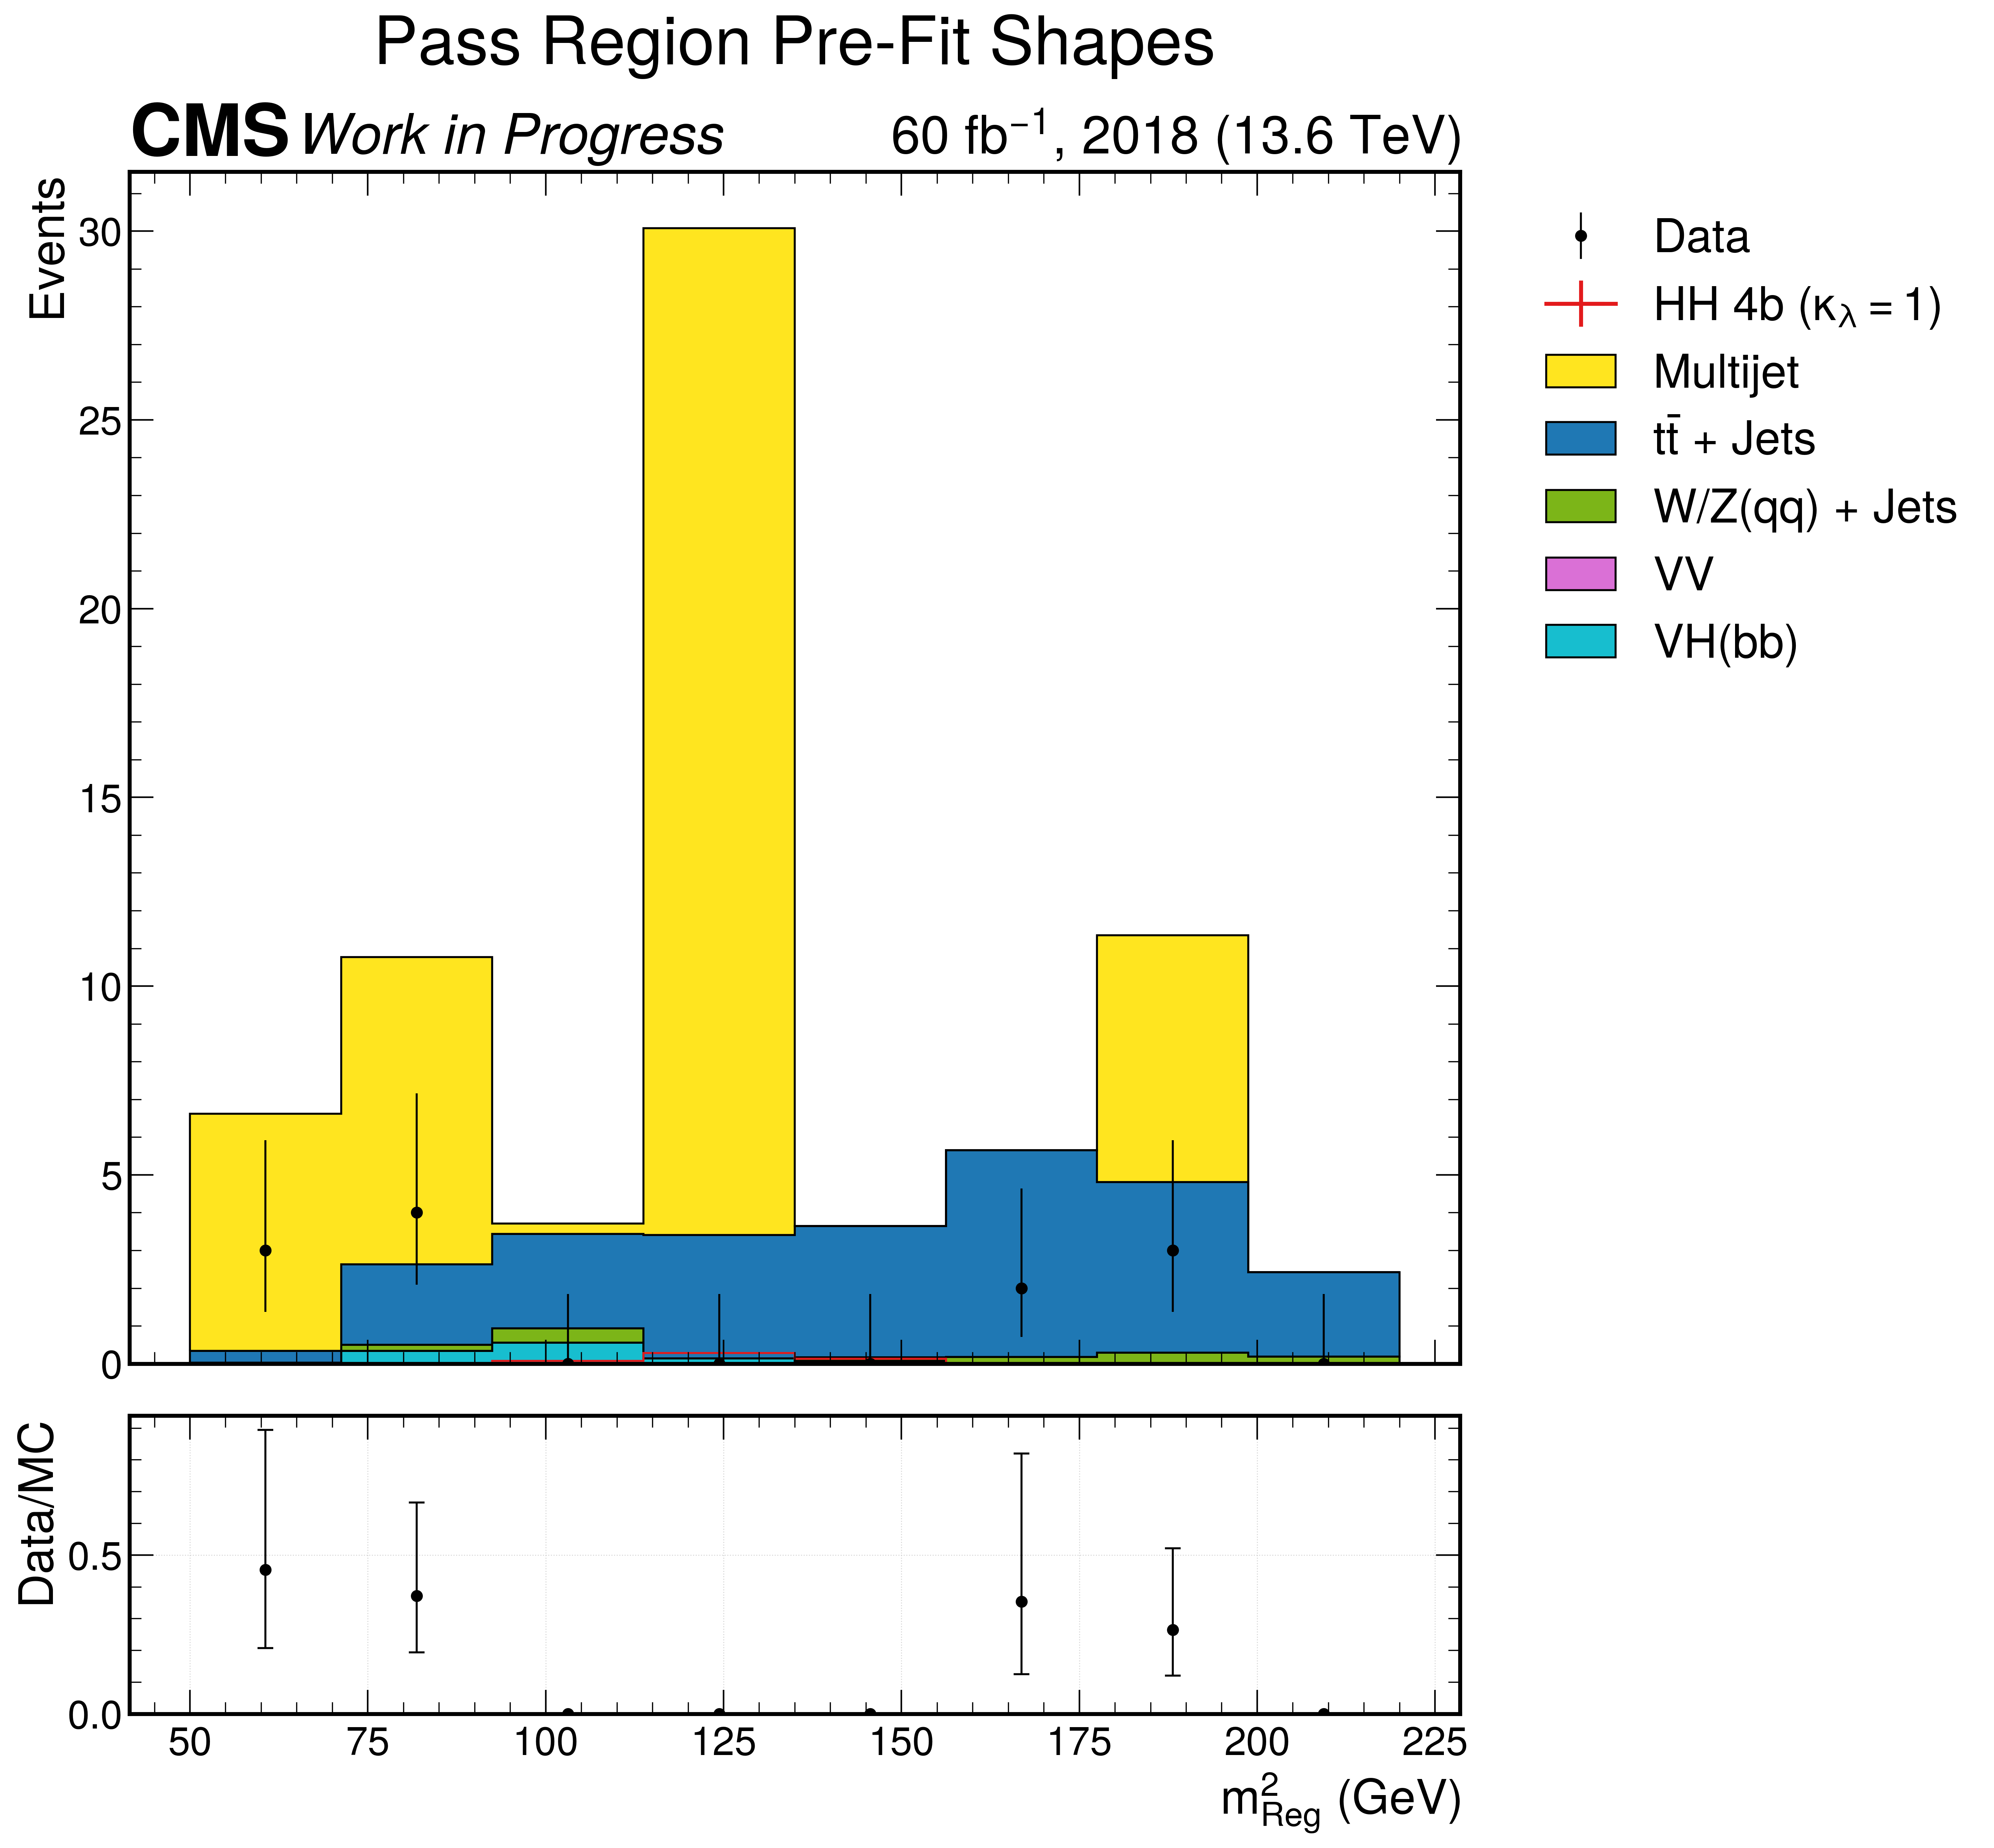

fail


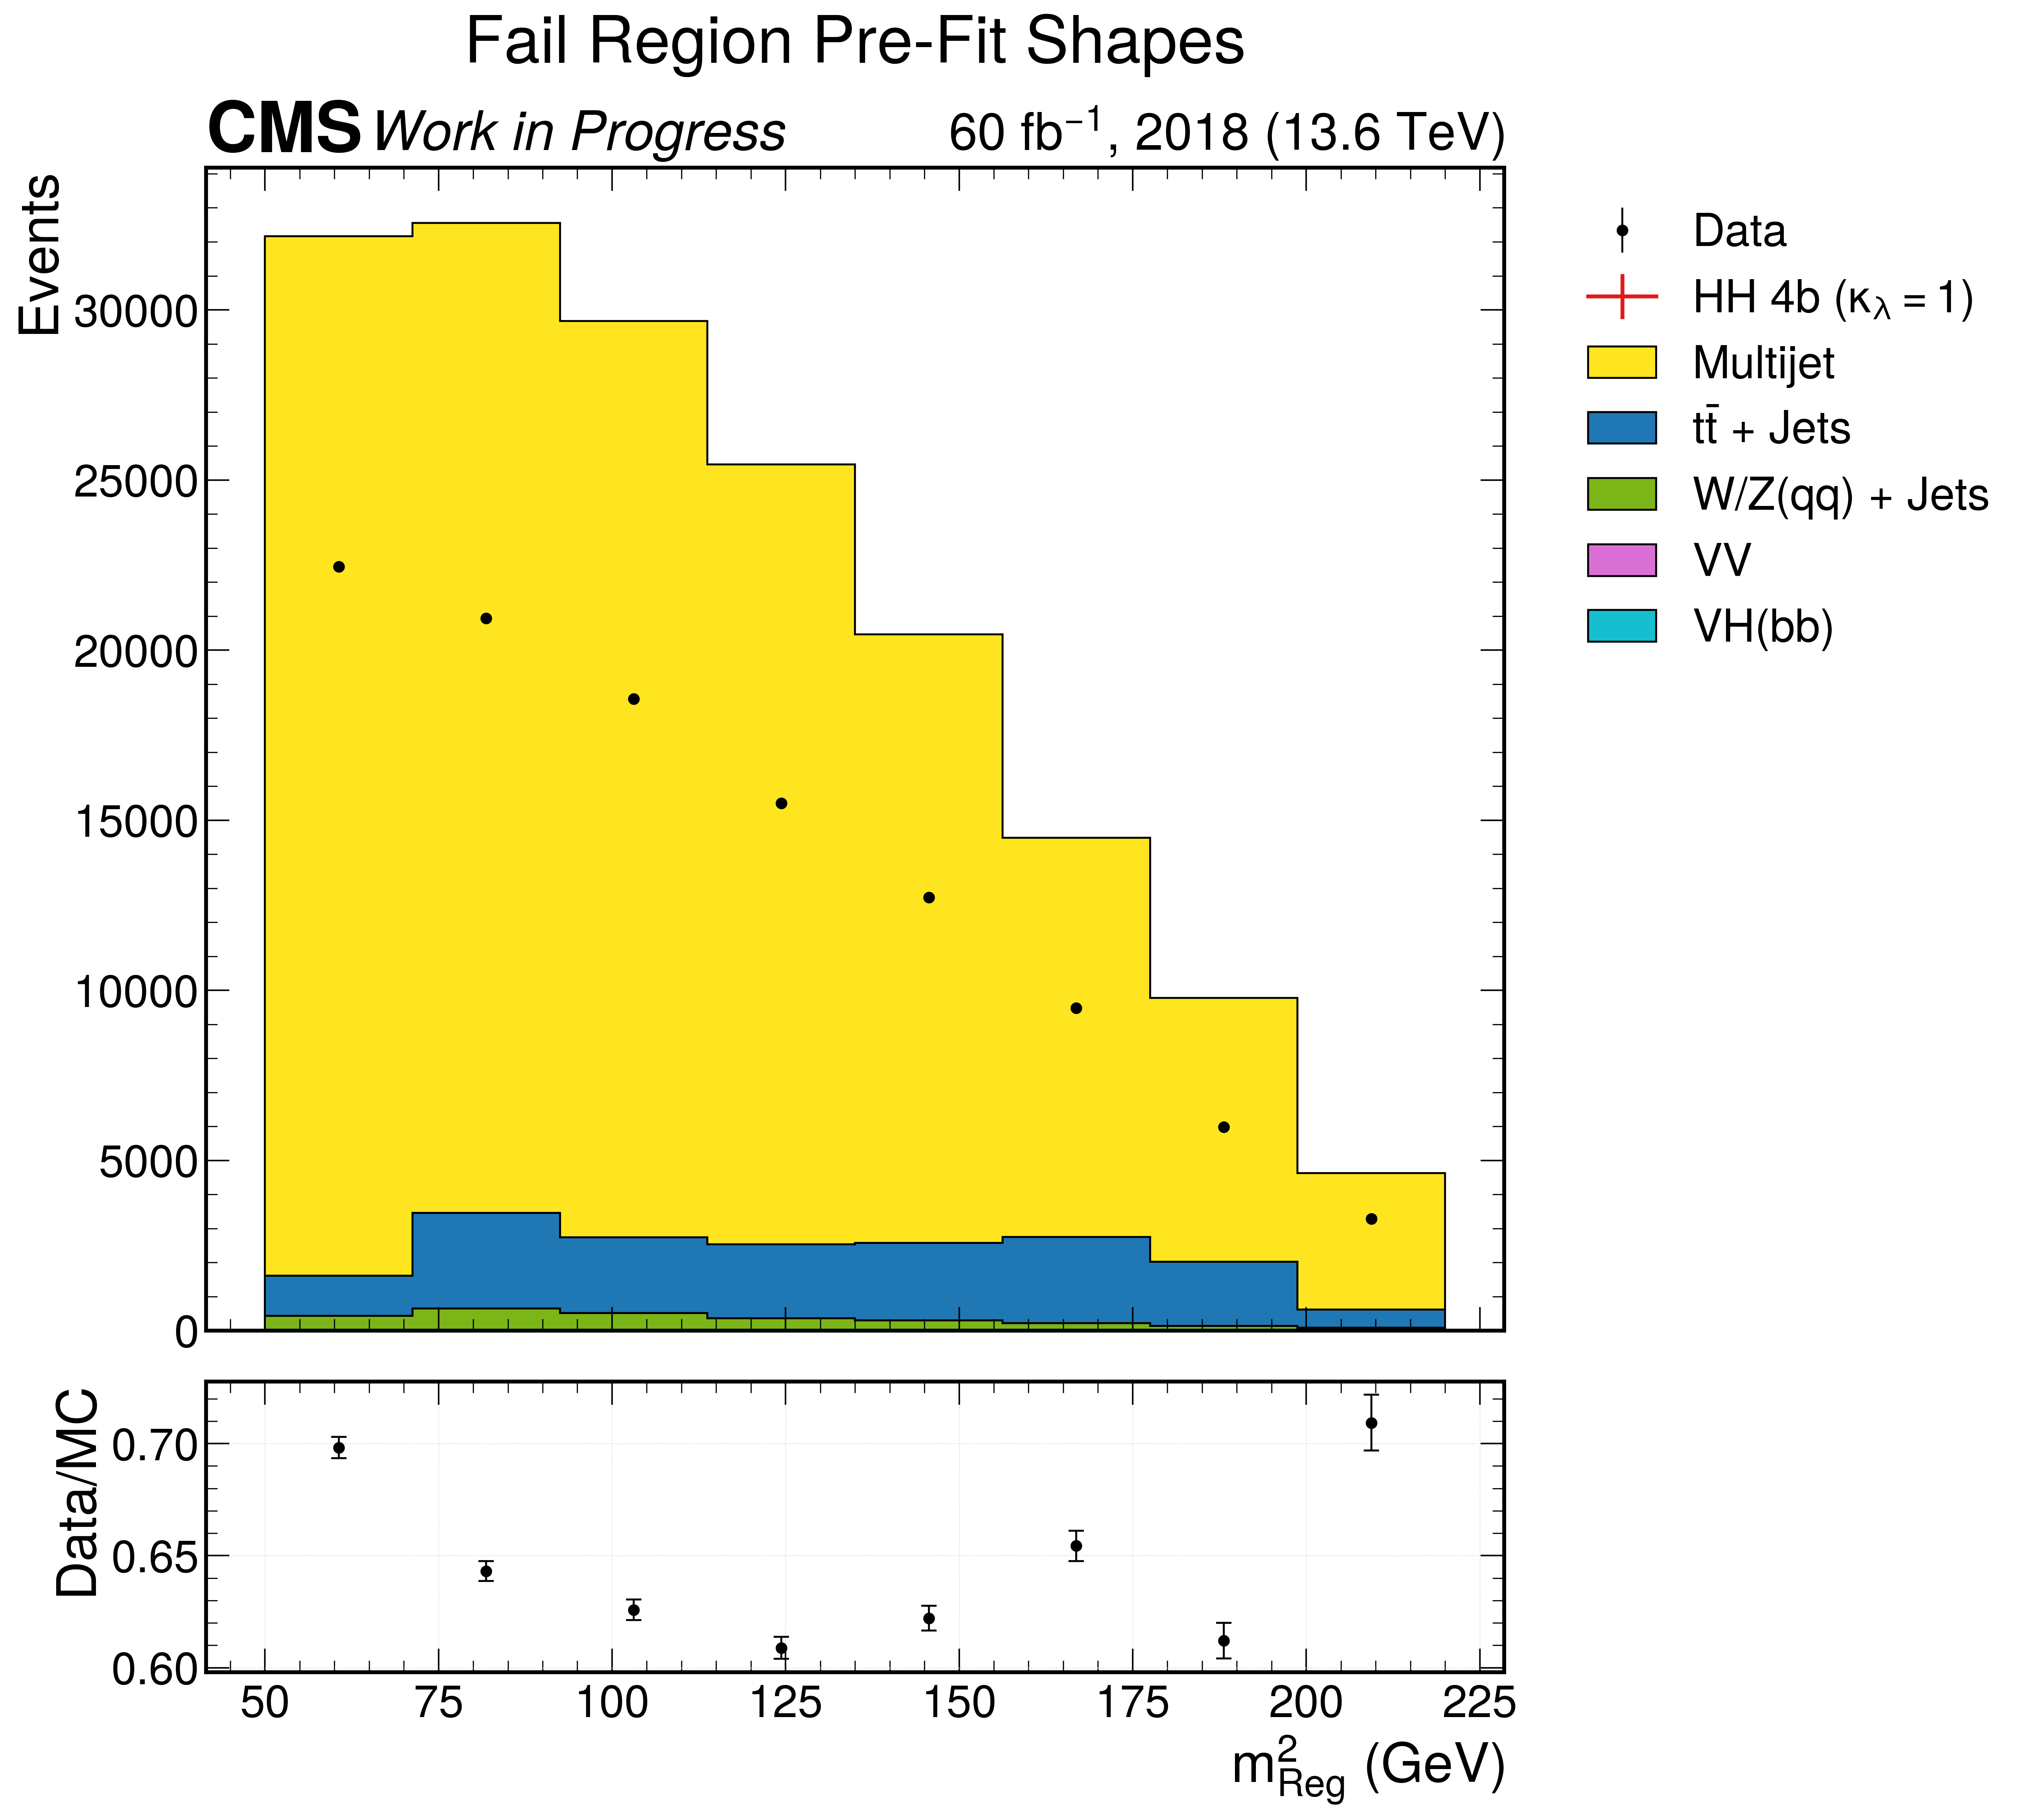

In [24]:
templates = postprocessing.get_templates(
    events_dict,
    bb_masks,
    year,
    sig_keys,
    selection_regions,
    [fit_shape_var],
    {},
    template_dir,
    ["qcd", "ttbar", "vjets", "diboson", "vhtobb"],
    plot_dir,
    cutflow,
    weight_key="weight",
    # weight_shifts=weight_shifts,
    show=True,
)

In [25]:
p = pd.read_csv(f"{template_dir}/cutflows/{year}/pass_cutflow.csv")
p

,Unnamed: 0,Preselection,0.985 ≤ bb0FatJetPNetXbb < 1,0.985 ≤ bb1FatJetPNetXbb < 1,bb0FatJetPt >= 350,bb1FatJetPt >= 310,105 ≤ bb0FatJetPNetMass < 135
0,hh4b,3.54,2.59,0.78,0.73,0.72,0.50
1,qcd,893917.93,94407.49,194.42,180.77,170.47,47.90
2,data,674263.00,65136.00,180.00,165.00,164.00,31.00
3,ttbar,107194.90,10580.08,155.81,145.22,142.73,24.07
4,vjets,23115.89,5079.68,12.82,12.11,11.98,1.45
5,diboson,160.80,66.32,1.99,1.87,1.87,0.00
6,gghtobb,200.69,108.22,0.27,0.23,0.23,0.13
7,vbfhtobb,46.25,27.77,0.03,0.03,0.03,0.03
8,vhtobb,58.71,32.50,3.16,3.01,2.99,1.15
9,tthtobb,295.08,67.10,1.79,1.61,1.60,0.72


In [ ]:
templates

In [ ]:
postprocessing.save_templates(
    templates,
    f"{template_dir}/{year}_templates.pkl",
    fit_shape_var,
)

In [ ]:
import pickle

with open(f"{template_dir}/{year}_templates.pkl", "rb") as f:
    templates2 = pickle.load(f)

In [ ]:
templates2

# BDT-based selection

In [26]:
import vector

vector.register_awkward()


def make_vector(events: pd.DataFrame, obj: str):
    """Create a ``vector`` object from the columns of the dataframe"""
    mstring = "PNetMass" if obj == "ak8FatJet" else "Mass"

    return vector.array(
        {
            "pt": events[f"{obj}Pt"],
            "phi": events[f"{obj}Phi"],
            "eta": events[f"{obj}Eta"],
            "M": events[f"{obj}{mstring}"],
        }
    )

In [27]:
# from https://github.com/LPC-HH/HHLooper/blob/master/python/xgboost/append_xgboost_discriminator_to_tree_withSystematics_MC_2018.py
_model_name = (
    f"{MAIN_DIR}/../data/model_xgboost_training_weights_qcd_and_ttbar_Run2_bdt_enhanced_v8p2.pkl"
)
import pickle

with open(_model_name, "rb") as pkl_file:
    model = pickle.load(pkl_file)
model

/Users/cmantill/miniconda3/envs/coffea/lib/python3.8/site-packages/xgboost/compat.py:85: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


XGBClassifier(base_score=0.5, booster=None, colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints=None,
              learning_rate=0.1, max_delta_step=0, max_depth=3,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              n_estimators=400, n_jobs=4, num_parallel_tree=1, random_state=0,
              reg_alpha=0, reg_lambda=1.0, scale_pos_weight=1, subsample=1,
              tree_method=None, validate_parameters=1, verbosity=2)

In [32]:
list(events.columns)

[('GenHiggsEta', 0),
 ('GenHiggsEta', 1),
 ('GenHiggsPhi', 0),
 ('GenHiggsPhi', 1),
 ('GenHiggsMass', 0),
 ('GenHiggsMass', 1),
 ('GenHiggsPt', 0),
 ('GenHiggsPt', 1),
 ('GenbEta', 0),
 ('GenbEta', 1),
 ('GenbEta', 2),
 ('GenbEta', 3),
 ('GenbPhi', 0),
 ('GenbPhi', 1),
 ('GenbPhi', 2),
 ('GenbPhi', 3),
 ('GenbMass', 0),
 ('GenbMass', 1),
 ('GenbMass', 2),
 ('GenbMass', 3),
 ('GenbPt', 0),
 ('GenbPt', 1),
 ('GenbPt', 2),
 ('GenbPt', 3),
 ('ak4JetHiggsMatch', 0),
 ('ak4JetHiggsMatch', 1),
 ('ak4JetHiggsMatch', 2),
 ('ak4JetHiggsMatch', 3),
 ('ak4JetHiggsMatch', 4),
 ('ak4JetHiggsMatch', 5),
 ('ak4JetHiggsMatchIndex', 0),
 ('ak4JetHiggsMatchIndex', 1),
 ('ak4JetHiggsMatchIndex', 2),
 ('ak4JetHiggsMatchIndex', 3),
 ('ak4JetHiggsMatchIndex', 4),
 ('ak4JetHiggsMatchIndex', 5),
 ('ak4JethadronFlavour', 0),
 ('ak4JethadronFlavour', 1),
 ('ak4JethadronFlavour', 2),
 ('ak4JethadronFlavour', 3),
 ('ak4JethadronFlavour', 4),
 ('ak4JethadronFlavour', 5),
 ('ak8FatJetHiggsMatch', 0),
 ('ak8FatJetHig

In [33]:
variables = [
    # branche name, BDT name
    ["hh_pt", "hh_pt", "$p_{T}^{HH}$ (GeV)", 40, 0, 5000],
    ["hh_eta", "hh_eta", "$\eta^{HH}$", 40, -5.0, 5.0],
    ["hh_mass", "hh_mass", "$m_{HH}$ (GeV)", 40, 0, 1500],
    ["met", "met", "$MET$ (GeV)", 60, 0, 600],
    ["fatJet1Tau3OverTau2", "fatJet1Tau3OverTau2", "fatJet1Tau3OverTau2", 50, 0.0, 1.0],
    ["fatJet2Tau3OverTau2", "fatJet2Tau3OverTau2", "fatJet2Tau3OverTau2", 50, 0.0, 1.0],
    ["fatJet1MassSD", "j1_mass_sd", "$M_{j1}$ (GeV)", 40, 0.0, 5000.0],
    ["fatJet1Pt", "j1_pt", "$p_{T}^{j1}$ (GeV)", 40, 0.0, 5000.0],
    ["fatJet1Eta", "j1_eta", "$\eta^{j1}$", 40, -2.5, 2.5],
    ["fatJet1PNetXbb", "fatJet1PNetXbb", "fatJet1PNetXbb", 40, -100, 100],
    ["fatJet1PNetQCDb", "fatJet1PNetQCDb", "fatJet1PNetQCDb", 40, -100, 100],
    ["fatJet1PNetQCDbb", "fatJet1PNetQCDbb", "fatJet1PNetQCDbb", 40, -100, 100],
    ["fatJet1PNetQCDothers", "fatJet1PNetQCDothers", "fatJet1PNetQCDothers", 40, -100, 100],
    ["fatJet2Pt", "j2_pt", "$p_{T}^{j2}$ (GeV)", 40, 0.0, 500.0],
    ["fatJet1PtOverMHH", "ptj1Omhh", "$p_{T}^{j1}/m_{HH}$", 40, 0.0, 1.0],
    ["fatJet2PtOverMHH", "ptj2Omhh", "$p_{T}^{j2}/m_{HH}$", 40, 0.0, 0.7],
    ["ptj2_over_ptj1", "ptj2Optj1", "$p_{T}^{j2}/p_{T}^{j1}$", 40, 0.5, 1.0],
]
var_names = [x[0] for x in variables]


def bdt_dataframe(key):
    events = events_dict[key]
    bb_mask = bb_masks[key]
    events_bdt = pd.DataFrame()
    events_bdt["fatJet1Pt"] = utils.get_feat(events, "bb0FatJetPt", bb_mask)
    events_bdt["fatJet1Eta"] = utils.get_feat(events, "bb0FatJetEta", bb_mask)
    events_bdt["fatJet1Phi"] = utils.get_feat(events, "bb0FatJetPhi", bb_mask)
    events_bdt["fatJet1Mass"] = utils.get_feat(events, "bb0FatJetMsd", bb_mask)

    events_bdt["fatJet2Pt"] = utils.get_feat(events, "bb1FatJetPt", bb_mask)
    events_bdt["fatJet2Eta"] = utils.get_feat(events, "bb1FatJetEta", bb_mask)
    events_bdt["fatJet2Phi"] = utils.get_feat(events, "bb1FatJetPhi", bb_mask)
    events_bdt["fatJet2Mass"] = utils.get_feat(events, "bb1FatJetMsd", bb_mask)

    events_bdt["fatJet1PNetXbb"] = utils.get_feat(events, "bb0FatJetPNetXbb", bb_mask)
    # events_bdt["fatJet1PNetQCDb"] = utils.get_feat(events, "bb0FatJetPNetXbb", bb_mask) # FIXME
    # events_bdt["fatJet1PNetQCDbb"] = utils.get_feat(events, "bb0FatJetPNetXbb", bb_mask)  # FIXME
    # events_bdt["fatJet1PNetQCDothers"] = utils.get_feat(events, "bb0FatJetPNetXbb", bb_mask)  # FIXME
    events_bdt["fatJet1PNetQCDb"] = utils.get_feat(events, "bb0FatJetPNetQCDb", bb_mask)
    events_bdt["fatJet1PNetQCDbb"] = utils.get_feat(events, "bb0FatJetPNetQCDbb", bb_mask)
    events_bdt["fatJet1PNetQCDothers"] = utils.get_feat(events, "bb0FatJetPNetQCDothers", bb_mask)

    events_bdt["fatJet1MassSD"] = utils.get_feat(events, "bb0FatJetMsd", bb_mask)

    h1 = utils.make_vector(events, "bb0FatJet", bb_mask=bb_mask, mstring="Msd")
    h2 = utils.make_vector(events, "bb1FatJet", bb_mask=bb_mask, mstring="Msd")
    hh = h1 + h2
    events_bdt["hh_pt"] = hh.pt
    events_bdt["hh_eta"] = hh.eta
    events_bdt["hh_mass"] = hh.mass

    # events_bdt["met"]= utils.get_feat(events, "ht") # FIXME
    # events_bdt["fatJet1Tau3OverTau2"] = utils.get_feat(events, "bb0FatJetPNetXjj", bb_mask) # FIXME
    # events_bdt["fatJet2Tau3OverTau2"] = utils.get_feat(events, "bb1FatJetPNetXjj", bb_mask) # FIXME
    events_bdt["met"] = utils.get_feat(events, "MET_pt")
    events_bdt["fatJet1Tau3OverTau2"] = utils.get_feat(events, "bb0FatJetTau3OverTau2", bb_mask)
    events_bdt["fatJet2Tau3OverTau2"] = utils.get_feat(events, "bb1FatJetTau3OverTau2", bb_mask)
    events_bdt["fatJet1PtOverMHH"] = events_bdt["fatJet1Pt"] / (hh.mass)
    events_bdt["fatJet2PtOverMHH"] = events_bdt["fatJet2Pt"] / (hh.mass)
    events_bdt["ptj2_over_ptj1"] = events_bdt["fatJet2Pt"] / events_bdt["fatJet1Pt"]

    events_bdt = events_bdt[var_names]
    # getting a numpy array from two pandas data frames
    x_test = events_bdt.values
    # creating numpy array for target variables
    np.zeros(len(events_bdt))
    # predict
    y_pred = model.predict_proba(x_test)[:, 1]

    events_bdt["bdt_prediction"] = y_pred

    events_bdt["fatJet1PNetMass"] = utils.get_feat(events, "bb0FatJetPNetMass", bb_mask)
    events_bdt["fatJet2PNetMass"] = utils.get_feat(events, "bb1FatJetPNetMass", bb_mask)
    events_bdt["weight"] = utils.get_feat(events, "weight")
    events_bdt["fatJet2PNetXbb"] = utils.get_feat(events, "bb1FatJetPNetXbb", bb_mask)

    return events_bdt

In [34]:
events_bdt_dict = {}
for key in ["hh4b", "qcd", "ttbar", "vjets", "diboson", "vhtobb", "data"]:
    print(key)
    events_bdt_dict[key] = bdt_dataframe(key)

hh4b
qcd
ttbar
vjets
diboson
vhtobb
data


In [35]:
print(len(events_bdt_dict["qcd"]["weight"]))
print(len(events_dict["qcd"]["weight"]))

200547
200547


pass


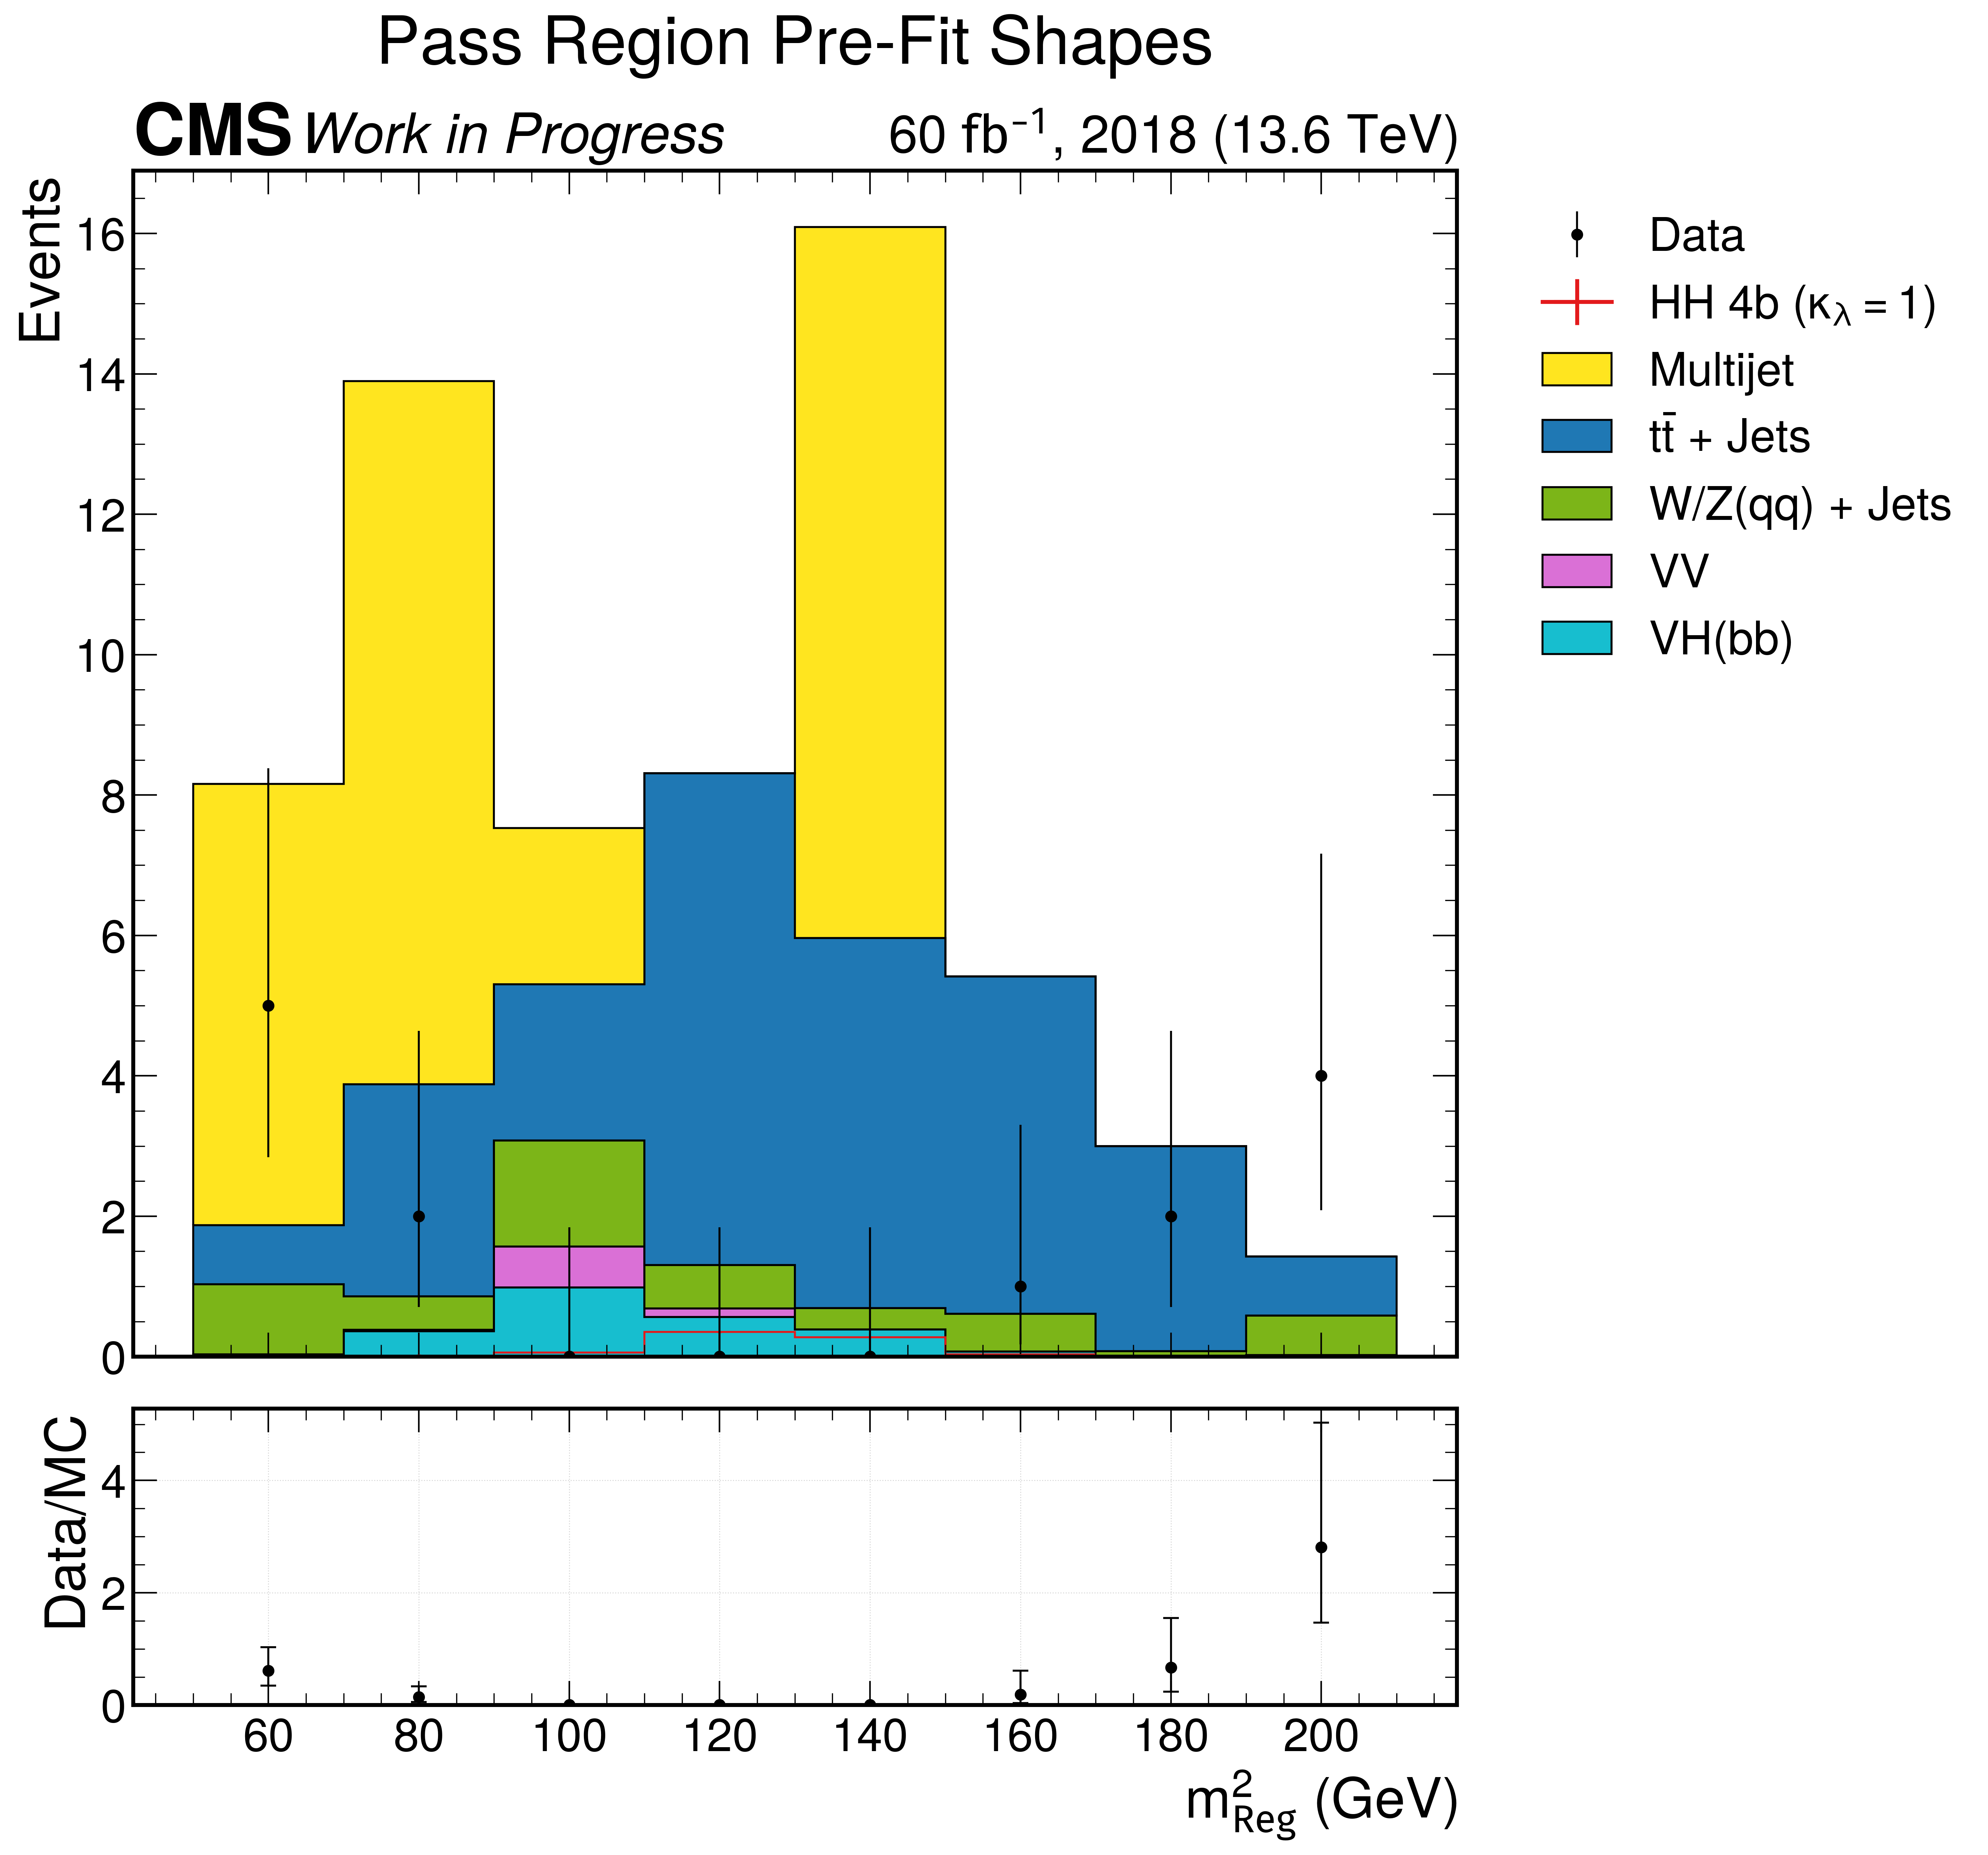

fail


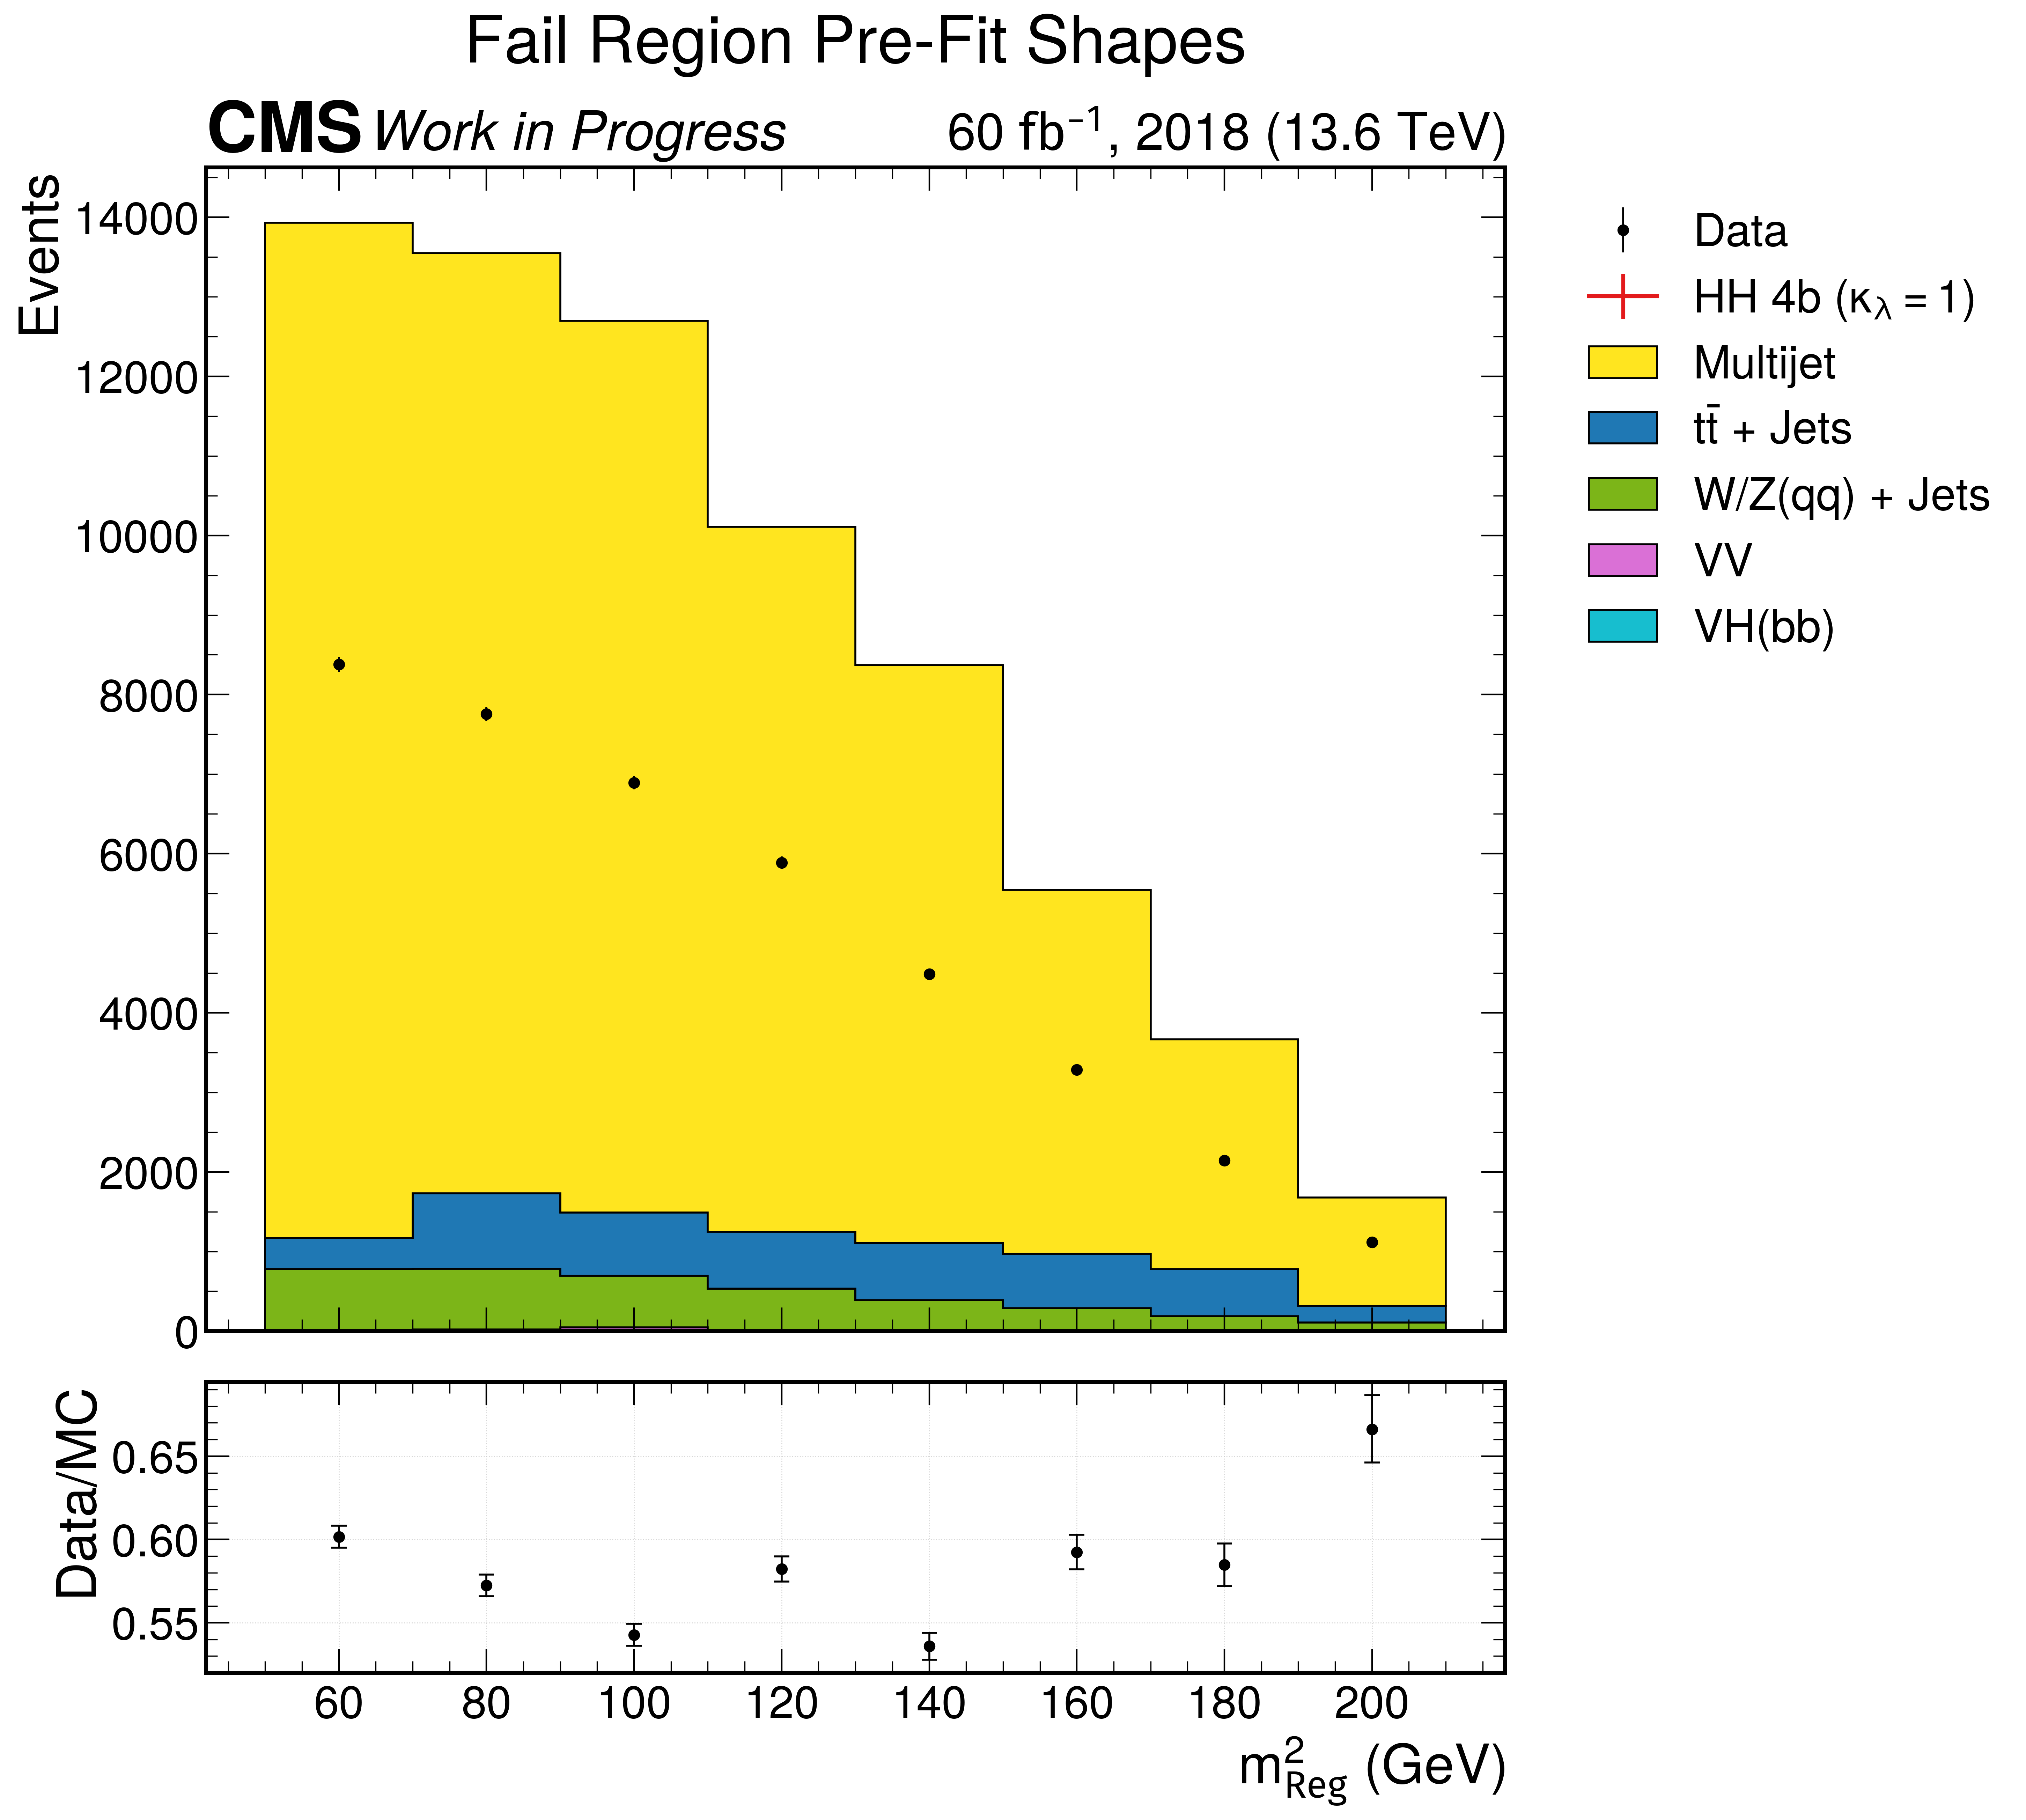

Saved templates to templates/24Feb1_2018_bdt//2018_templates.pkl


In [39]:
selection_regions = {
    # category 1
    "pass": Region(
        cuts={
            "fatJet1PNetXbb": [0.8, CUT_MAX_VAL],
            "fatJet2PNetXbb": [0.980, CUT_MAX_VAL],
            "fatJet1Pt": [300, CUT_MAX_VAL],
            "fatJet2Pt": [300, CUT_MAX_VAL],
            "fatJet1MassSD": [50, CUT_MAX_VAL],
            "fatJet2PNetMass": [50, CUT_MAX_VAL],
            # "fatJet2PNetMass": [110, 140],
            "bdt_prediction": [0.43, CUT_MAX_VAL],
        },
        label="Pass",
    ),
    "fail": Region(
        cuts={
            "fatJet2PNetXbb": [0.0, 0.950],
            "fatJet1Pt": [300, CUT_MAX_VAL],
            "fatJet2Pt": [300, CUT_MAX_VAL],
            "fatJet1MassSD": [50, CUT_MAX_VAL],
            "fatJet2PNetMass": [50, CUT_MAX_VAL],
            "bdt_prediction": [0.03, CUT_MAX_VAL],
        },
        label="Fail",
    ),
}

fit_shape_var = ShapeVar(
    "fatJet2PNetMass",
    r"$m^{2}_\mathrm{Reg}$ (GeV)",
    [8, 50, 210],
    reg=True,
    blind_window=[90, 150],
)

template_dir = f"templates/{date}_bdt/"
plot_dir = f"{plot_dir}_bdt"
_ = os.system(f"mkdir -p {plot_dir}")
_ = os.system(f"mkdir -p {template_dir}/cutflows/{year}")

templates = postprocessing.get_templates(
    events_bdt_dict,
    bb_masks,
    year,
    sig_keys,
    selection_regions,
    [fit_shape_var],
    {},
    template_dir,
    ["qcd", "ttbar", "vjets", "diboson", "vhtobb"],
    plot_dir,
    cutflow,
    weight_key="weight",
    # weight_shifts=weight_shifts,
    show=True,
)

postprocessing.save_templates(
    templates,
    f"{template_dir}/{year}_templates.pkl",
    fit_shape_var,
)

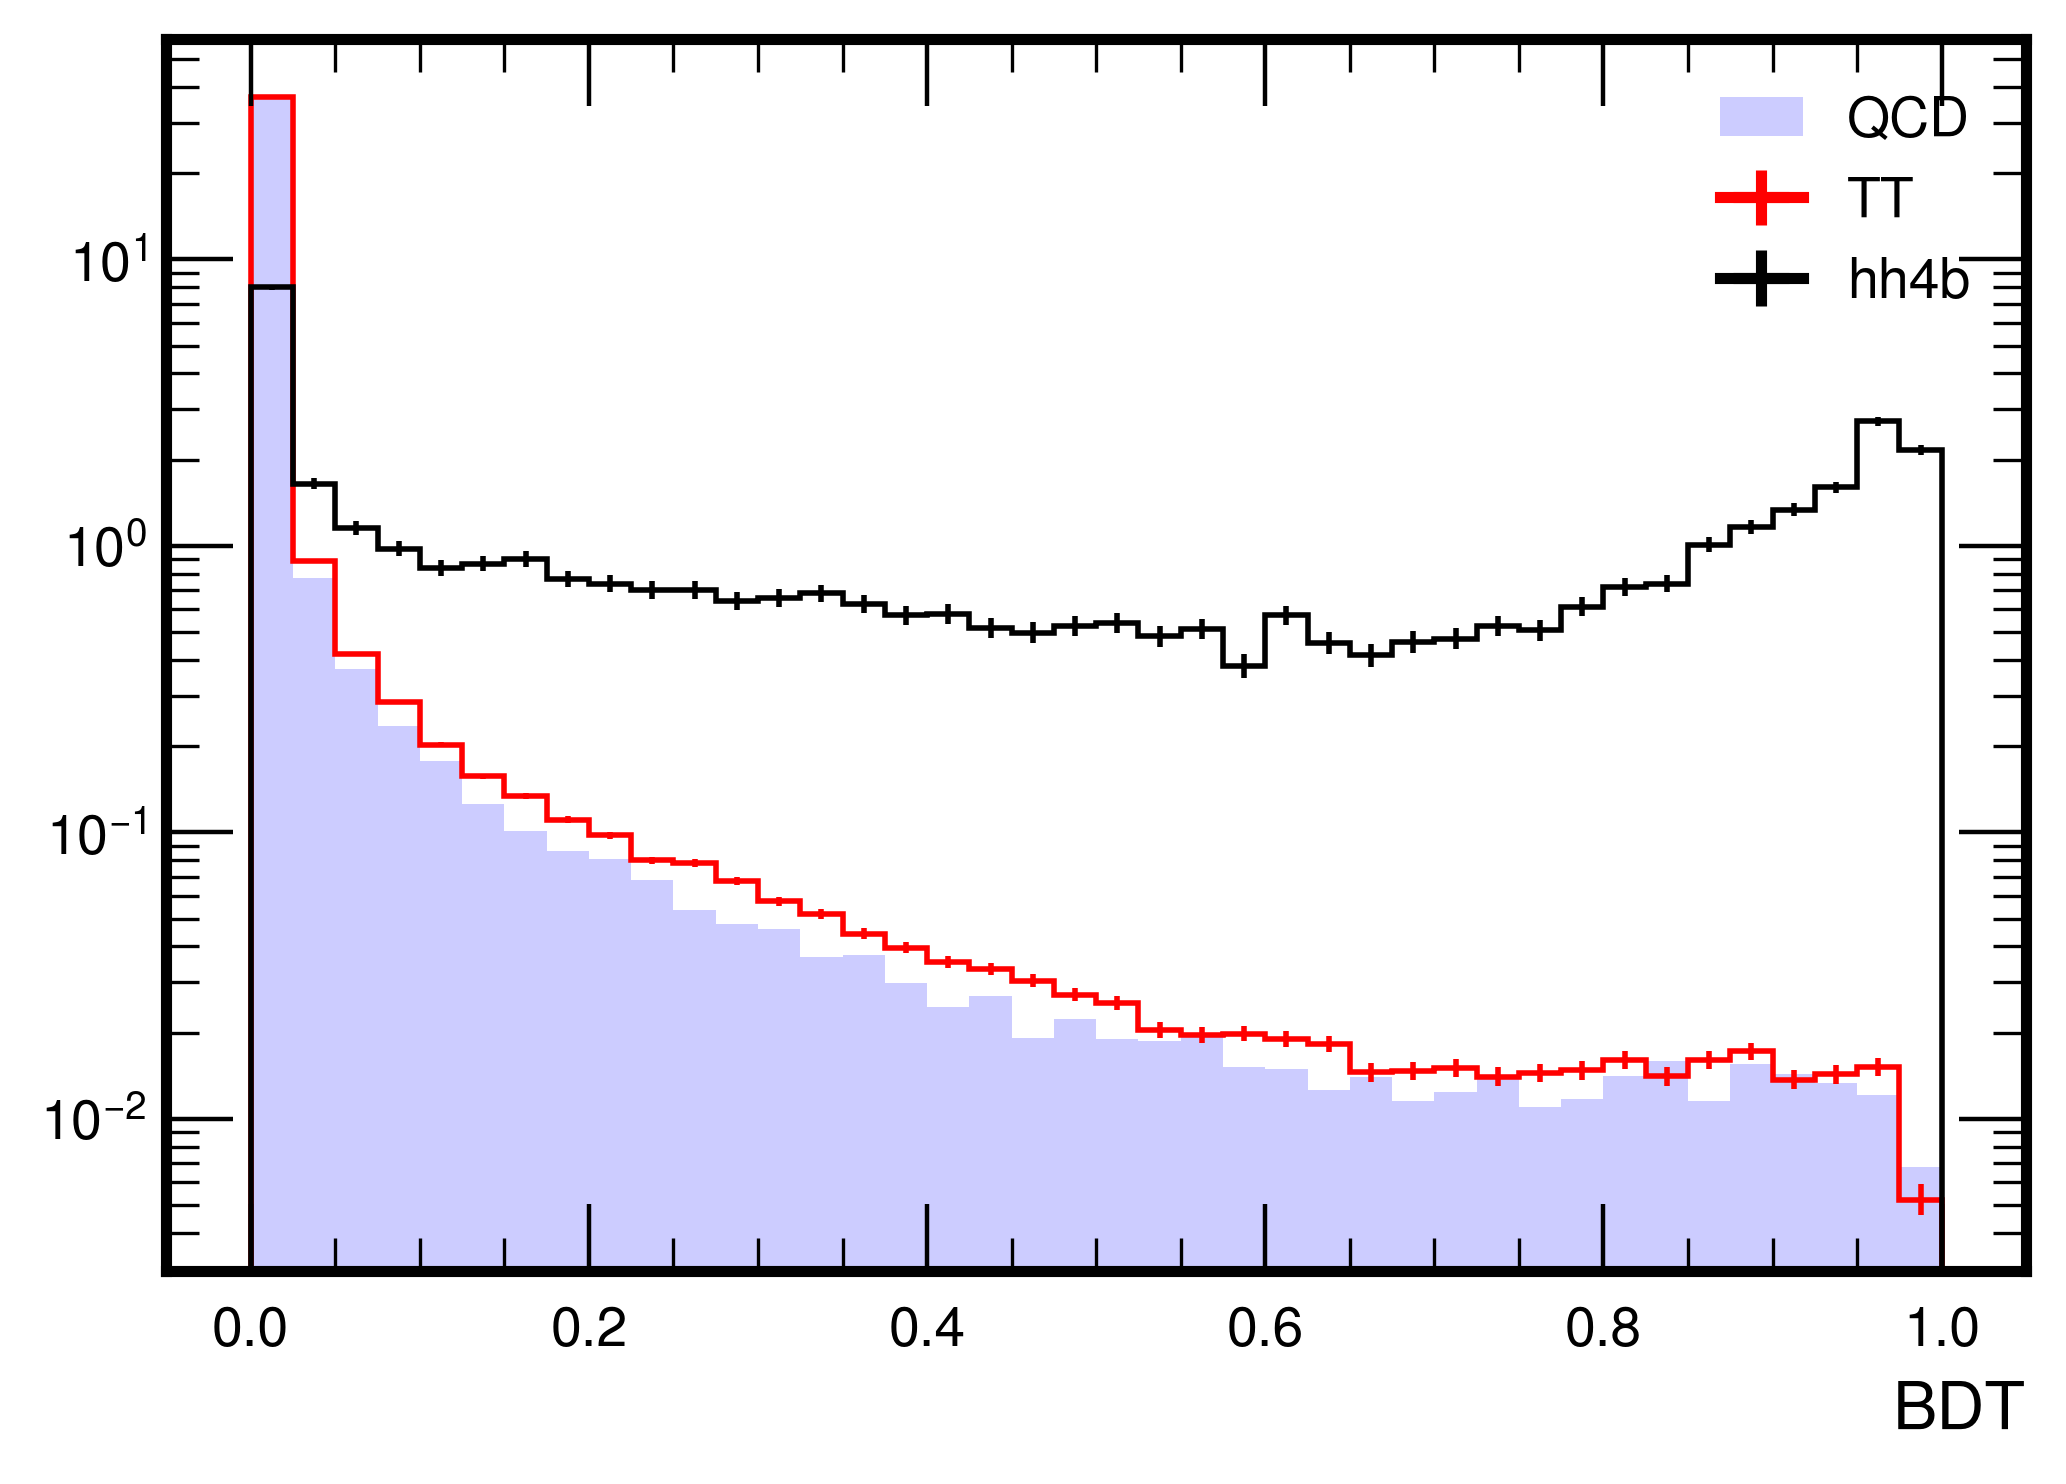

In [36]:
import hist
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import mplhep as hep

hep.style.use(["CMS", "firamath"])

formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
plt.rcParams.update({"font.size": 12})
plt.rcParams["lines.linewidth"] = 2
plt.rcParams["grid.color"] = "#CCCCCC"
plt.rcParams["grid.linewidth"] = 0.5
plt.rcParams["figure.edgecolor"] = "none"

bdt_axis = hist.axis.Regular(40, 0, 1, name="bdt", label=r"BDT")
cat_axis = hist.axis.StrCategory([], name="cat", growth=True)

h = hist.Hist(bdt_axis, cat_axis)

keys = ["ttbar", "qcd", "hh4b"]
for key in keys:
    h.fill(bdt=events_bdt_dict[key]["bdt_prediction"].to_numpy(), cat=key)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
hep.histplot(
    h[{"cat": "qcd"}],
    ax=ax,
    label="QCD",
    histtype="fill",
    color="blue",
    alpha=0.2,
    linewidth=1,
    density=True,
)
hep.histplot(
    h[{"cat": "ttbar"}],
    ax=ax,
    label="TT",
    color="red",
    linewidth=1,
    density=True,
)
hep.histplot(
    h[{"cat": "hh4b"}],
    ax=ax,
    label="hh4b",
    histtype="step",
    linewidth=1,
    color="black",
    density=True,
)
ax.set_yscale("log")
ax.legend()

/var/folders/np/80b736zs2753ch8xq6lq33d80000gq/T/ipykernel_90493/3881439899.py:25: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  weights = np.concatenate(np.array(weights), axis=0)


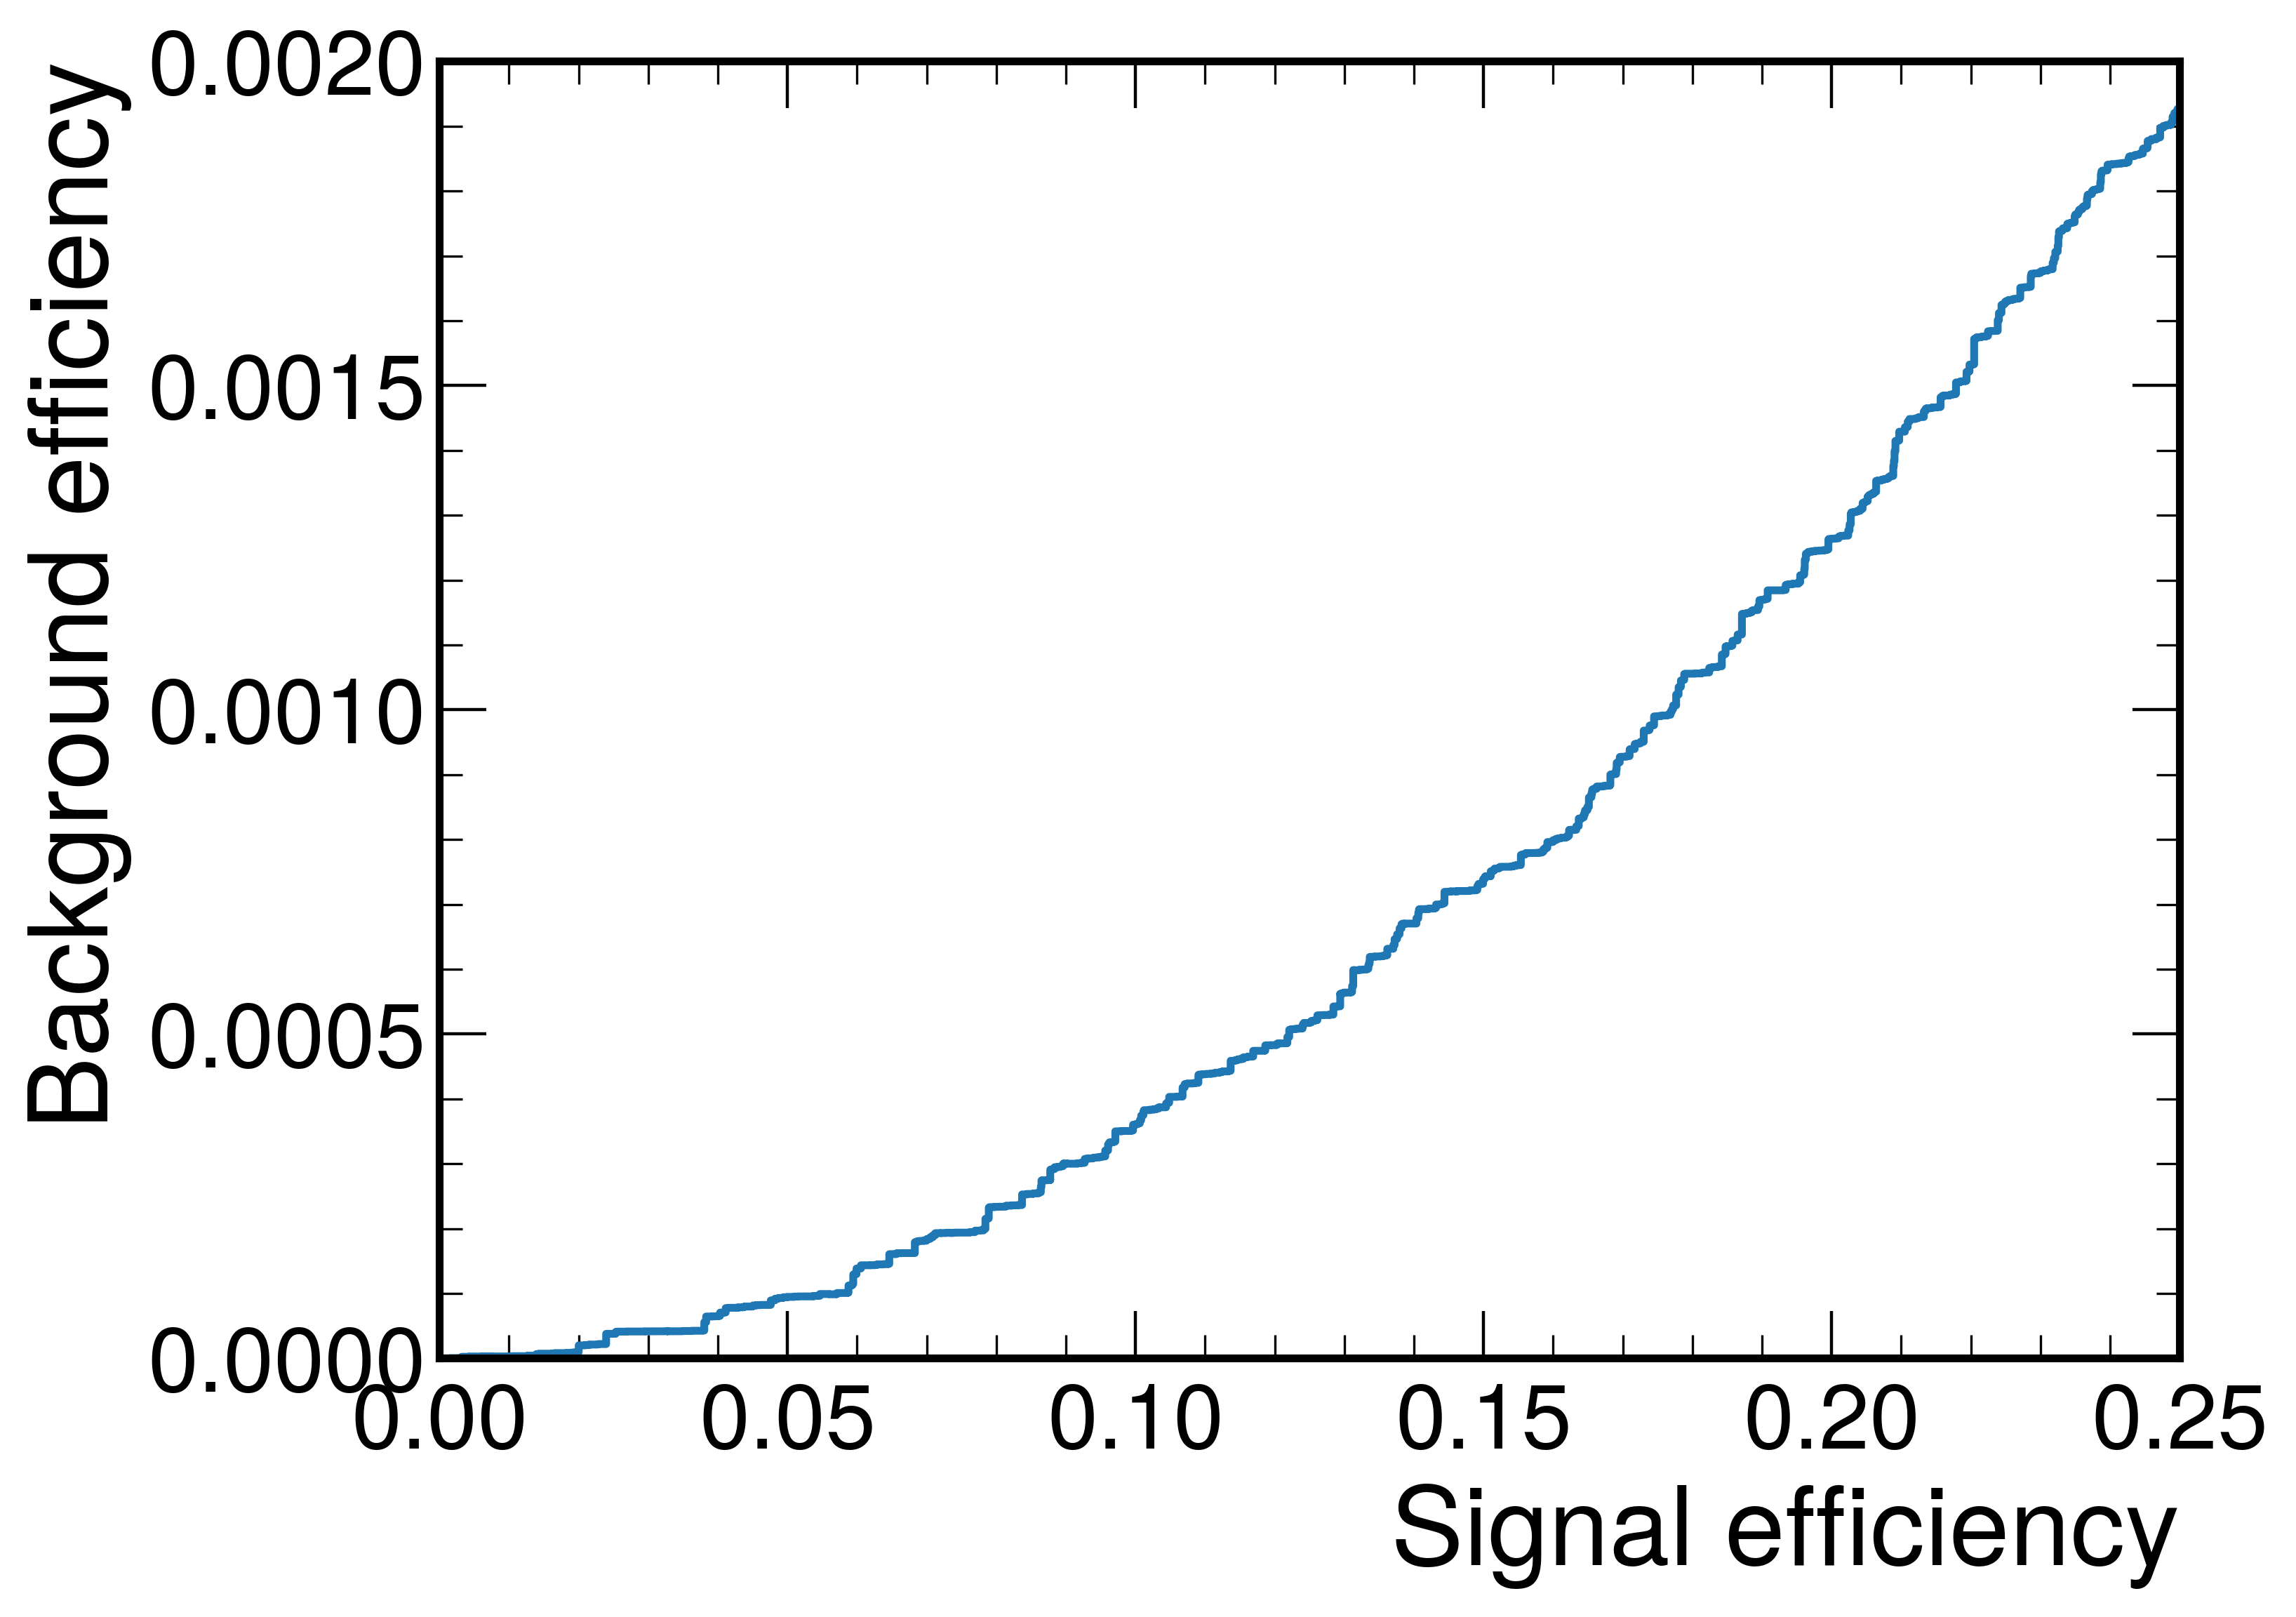

In [38]:
sig_jets_score = events_bdt_dict["hh4b"]["bdt_prediction"].values
sig_jets_score.shape

bg_jets_score = np.concatenate(
    [
        events_bdt_dict["ttbar"]["bdt_prediction"].values,
        events_bdt_dict["qcd"]["bdt_prediction"].values,
    ]
)
bg_jets_score.shape

sig_key = "hh4b"
bg_keys = ["qcd", "ttbar"]

y_true = np.concatenate(
    [
        np.ones(len(sig_jets_score)),
        np.zeros(len(bg_jets_score)),
    ]
)

weights = []
for key in ["qcd", "ttbar", "hh4b"]:
    weights.append(events_bdt_dict[key]["weight"].values)
weights = np.concatenate(np.array(weights), axis=0)

scores = np.concatenate((sig_jets_score, bg_jets_score))

fpr, tpr, thresholds = roc_curve(y_true, scores, sample_weight=weights)

plt.figure(figsize=(8, 6))
plt.plot(
    tpr,
    fpr,
    linewidth=2,
)
plt.xlabel("Signal efficiency")
plt.ylabel("Background efficiency")
plt.xlim([0, 0.25])
plt.ylim([0, 0.002])
plt.legend(loc="upper left")